In [ ]:
!pip install --upgrade datasets huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.4/503.4 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.4/563.4 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 17.9 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface-hub 0.34.4
    Uninstalling huggingface-hub-0.34.4:
      Successfully uninstalled huggingface-hub-0.34.4
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "

Loading the 'Vietnamese' subset from the 'tungvu3196/vlm-projects-multi-lang-final' dataset...
Dataset subset loaded successfully.
Loading dataset: tungvu3196/vlm-projects-multi-lang-final...
Dataset loaded successfully.

Combining all splits for a global analysis...

Converting to pandas DataFrame for analysis (this may take a moment)...
Analysis will be performed on 12325 total rows.


Analyzing columns:   0%|          | 0/8 [00:00<?, ?it/s]


--- Analysis for column: 'Q1' ---
  Completeness:
    - Total Rows: 12325
    - Non-Empty Entries: 12325 (100.0%)
    - Missing/Empty Entries: 0 (0.0%)
  Uniqueness: 33 unique values
  Text Length (for non-empty values):
    - Characters: Min=19, Avg=26.8, Max=40
    - Words: Min=4, Avg=5.7, Max=8
  Top 5 Most Common Values:
    - "Đánh dấu vùng bị bệnh?..." : 941 times (7.6%)
    - "Xác định/Khoanh vùng khu vực tổn thương?..." : 815 times (6.6%)
    - "Làm nổi bật vị trí tổn thương?..." : 783 times (6.4%)
    - "Nhận dạng vùng bị bệnh?..." : 733 times (5.9%)
    - "Nhận dạng vùng bệnh?..." : 699 times (5.7%)

--- Analysis for column: 'A1' ---
  Completeness:
    - Total Rows: 12325
    - Non-Empty Entries: 12325 (100.0%)
    - Missing/Empty Entries: 0 (0.0%)
  Uniqueness: 12197 unique values
  Text Length (for non-empty values):
    - Characters: Min=24, Avg=266.6, Max=661
    - Words: Min=4, Avg=12.9, Max=32
  A1 Specific (Bounding Boxes):
    - Avg Boxes per Entry: 3.23
    - Max B

/tmp/ipython-input-134338428.py:176: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Unique Values', y='Column', data=unique_counts_df, palette='viridis')


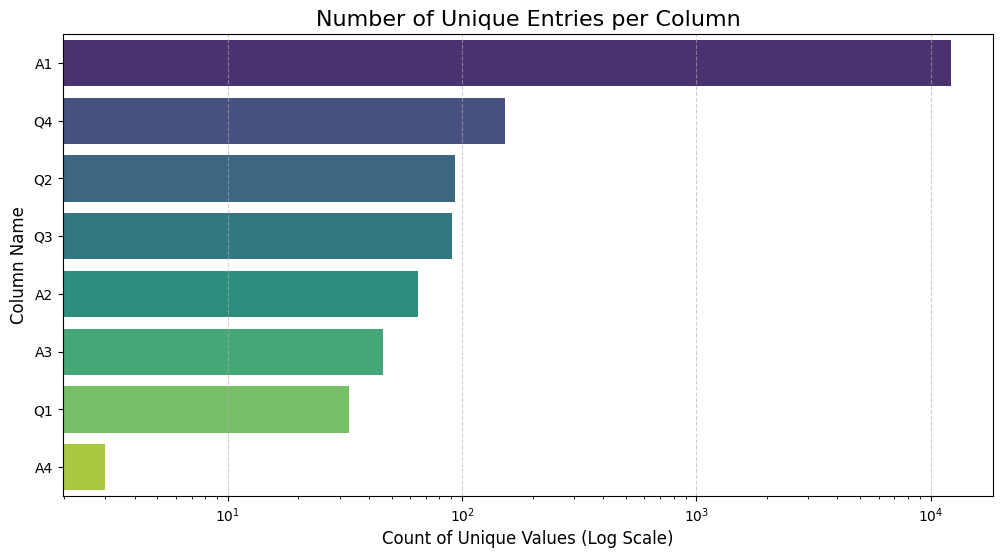

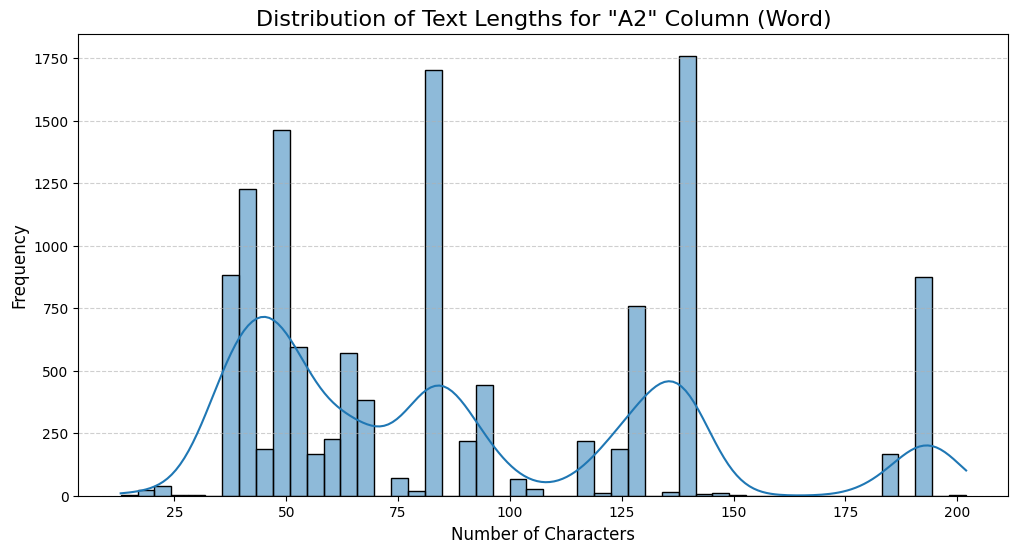

In [ ]:
!pip install -q datasets pandas matplotlib seaborn

from datasets import load_dataset, concatenate_datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
from tqdm.auto import tqdm # For progress bars

# --- Configuration ---
HF_DATASET_NAME = "tungvu3196/vlm-projects-multi-lang-final"
subset_name = "Vietnamese"

# 2. Load the specific 'Vietnamese' subset of the dataset
print(f"Loading the '{subset_name}' subset from the '{HF_DATASET_NAME}' dataset...")
# dataset_subset = load_dataset(HF_DATASET_NAME, name=subset_name)
print("Dataset subset loaded successfully.")
FOCUS_COLUMNS = ['Q1', 'A1', 'Q2', 'A2', 'Q3', 'A3', 'Q4', 'A4']

# --- Step 1: Load and Prepare the Dataset ---
print(f"Loading dataset: {HF_DATASET_NAME}...")
try:
    hf_dataset_dict = load_dataset(HF_DATASET_NAME, name=subset_name)
    print("Dataset loaded successfully.")

    all_splits_list = [split for name, split in hf_dataset_dict.items()]
    if not all_splits_list: raise ValueError("No data splits found.")

    print("\nCombining all splits for a global analysis...")
    combined_dataset = concatenate_datasets(all_splits_list)

    print("\nConverting to pandas DataFrame for analysis (this may take a moment)...")
    df_for_analysis = combined_dataset.to_pandas()
    print(f"Analysis will be performed on {len(df_for_analysis)} total rows.")

except Exception as e:
    print(f"An error occurred: {e}"); exit()


# --- Step 2: Define Analysis Function ---
def analyze_column(df, column_name):
    """Performs a detailed statistical analysis on a specific DataFrame column."""

    # Ensure the column exists
    if column_name not in df.columns:
        print(f"\n--- Analysis for column: '{column_name}' ---")
        print("  Column not found in dataset. Skipping.")
        return None

    print(f"\n--- Analysis for column: '{column_name}' ---")

    stats = {}
    col_series = df[column_name]

    # 1. Completeness
    total_entries = len(col_series)
    # Treat None, NaN, and empty/whitespace-only strings as "missing"
    non_empty_series = col_series.dropna().astype(str).str.strip()
    non_empty_count = non_empty_series[non_empty_series != ''].count()
    missing_count = total_entries - non_empty_count

    stats['Total Rows'] = total_entries
    stats['Non-Empty'] = f"{non_empty_count} ({non_empty_count / total_entries:.1%})"
    stats['Missing/Empty'] = f"{missing_count} ({missing_count / total_entries:.1%})"

    print(f"  Completeness:")
    print(f"    - Total Rows: {stats['Total Rows']}")
    print(f"    - Non-Empty Entries: {stats['Non-Empty']}")
    print(f"    - Missing/Empty Entries: {stats['Missing/Empty']}")

    # 2. Uniqueness
    unique_count = non_empty_series[non_empty_series != ''].nunique()
    stats['Unique Values'] = unique_count
    print(f"  Uniqueness: {unique_count} unique values")

    # 3. Length Analysis (for non-empty strings)
    if non_empty_count > 0:
        char_lengths = non_empty_series[non_empty_series != ''].str.len()
        word_counts = non_empty_series[non_empty_series != ''].str.split().str.len()

        stats['Min Chars'] = int(char_lengths.min())
        stats['Avg Chars'] = f"{char_lengths.mean():.1f}"
        stats['Max Chars'] = int(char_lengths.max())

        stats['Min Words'] = int(word_counts.min())
        stats['Avg Words'] = f"{word_counts.mean():.1f}"
        stats['Max Words'] = int(word_counts.max())

        print("  Text Length (for non-empty values):")
        print(f"    - Characters: Min={stats['Min Chars']}, Avg={stats['Avg Chars']}, Max={stats['Max Chars']}")
        print(f"    - Words: Min={stats['Min Words']}, Avg={stats['Avg Words']}, Max={stats['Max Words']}")

        # 4. Special Analysis for A1 (Bbox count)
        if column_name == 'A1':
            def count_bboxes(bbox_str):
                try:
                    parsed = ast.literal_eval(bbox_str)
                    if isinstance(parsed, list):
                        # Handle nesting like [[...]]
                        if len(parsed) > 0 and isinstance(parsed[0], list):
                            return len(parsed)
                except (ValueError, SyntaxError):
                    return 0 # Not a valid list representation
                return 0

            bbox_counts = non_empty_series[non_empty_series != ''].apply(count_bboxes)
            stats['Avg BBoxes/Entry'] = f"{bbox_counts.mean():.2f}"
            stats['Max BBoxes/Entry'] = int(bbox_counts.max())
            print("  A1 Specific (Bounding Boxes):")
            print(f"    - Avg Boxes per Entry: {stats['Avg BBoxes/Entry']}")
            print(f"    - Max Boxes per Entry: {stats['Max BBoxes/Entry']}")

    # 5. Value Distribution
    print("  Top 5 Most Common Values:")
    if non_empty_count > 0:
        top_5 = non_empty_series[non_empty_series != ''].value_counts().head(5)
        for value, count in top_5.items():
            percentage = count / non_empty_count * 100
            print(f"    - \"{str(value)[:70]}...\" : {count} times ({percentage:.1f}%)")
    else:
        print("    - No values to display.")

    return {column_name: stats}


# --- Step 3: Run Analysis for All Focus Columns ---
all_stats = {}
column_stats_list = []

for column in tqdm(FOCUS_COLUMNS, desc="Analyzing columns"):
    stats_result = analyze_column(df_for_analysis, column)
    if stats_result:
        # For the summary table
        col_stats_for_df = stats_result[column]
        col_stats_for_df['Column'] = column
        column_stats_list.append(col_stats_for_df)
        # For the main dict
        all_stats.update(stats_result)

# --- Step 4: Display Summary Table ---
print("\n" + "="*50)
print(" " * 15 + "DATASET STATISTICS SUMMARY")
print("="*50)

if column_stats_list:
    summary_df = pd.DataFrame(column_stats_list)
    # Reorder columns for clarity
    summary_order = [
        'Column', 'Non-Empty', 'Missing/Empty', 'Unique Values',
        'Avg Chars', 'Min Chars', 'Max Chars', 'Avg Words'
    ]
    # Add A1-specific columns if they exist
    if 'Avg BBoxes/Entry' in summary_df.columns:
        summary_order.extend(['Avg BBoxes/Entry', 'Max BBoxes/Entry'])

    # Filter for columns that actually exist in the summary df
    final_summary_order = [col for col in summary_order if col in summary_df.columns]
    summary_df = summary_df[final_summary_order]

    print(summary_df.to_string(index=False))
else:
    print("No statistics were generated.")
print("="*50)


# --- Step 5: Visualizations ---
print("\n" + "="*50)
print(" " * 20 + "VISUALIZATIONS")
print("="*50)

# 1. Bar chart of unique value counts
if column_stats_list:
    unique_counts_df = summary_df[['Column', 'Unique Values']].sort_values('Unique Values', ascending=False)
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Unique Values', y='Column', data=unique_counts_df, palette='viridis')
    plt.title('Number of Unique Entries per Column', fontsize=16)
    plt.xlabel('Count of Unique Values (Log Scale)', fontsize=12)
    plt.ylabel('Column Name', fontsize=12)
    plt.xscale('log') # Use log scale if counts vary wildly
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

# 2. Histogram of text lengths for a key answer column (e.g., A2)
if 'A2' in df_for_analysis.columns:
    plt.figure(figsize=(12, 6))
    char_lengths_a2 = df_for_analysis['A2'].dropna().astype(str).str.len()
    sns.histplot(char_lengths_a2, bins=50, kde=True)
    plt.title('Distribution of Text Lengths for "A2" Column (Word)', fontsize=16)
    plt.xlabel('Number of Characters', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()


                    VISUALIZATIONS


/tmp/ipython-input-205471867.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


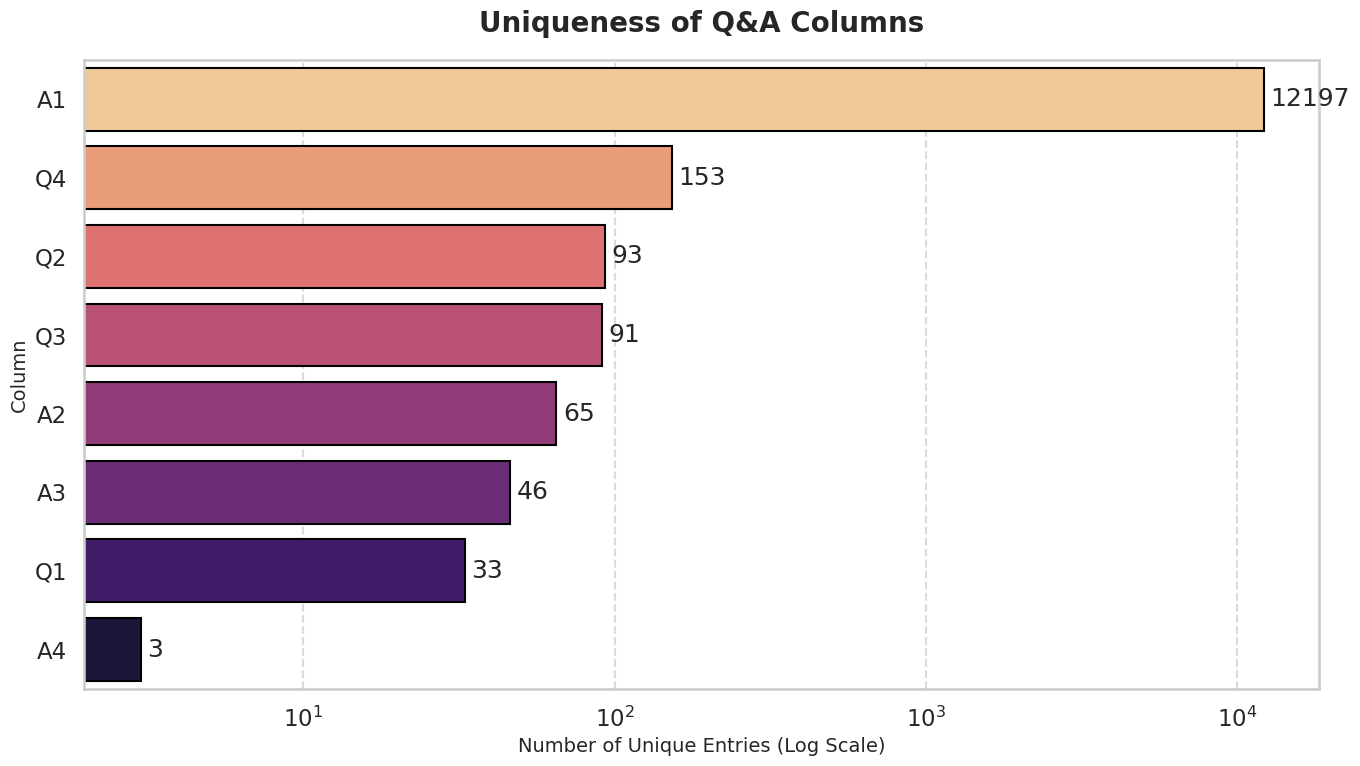

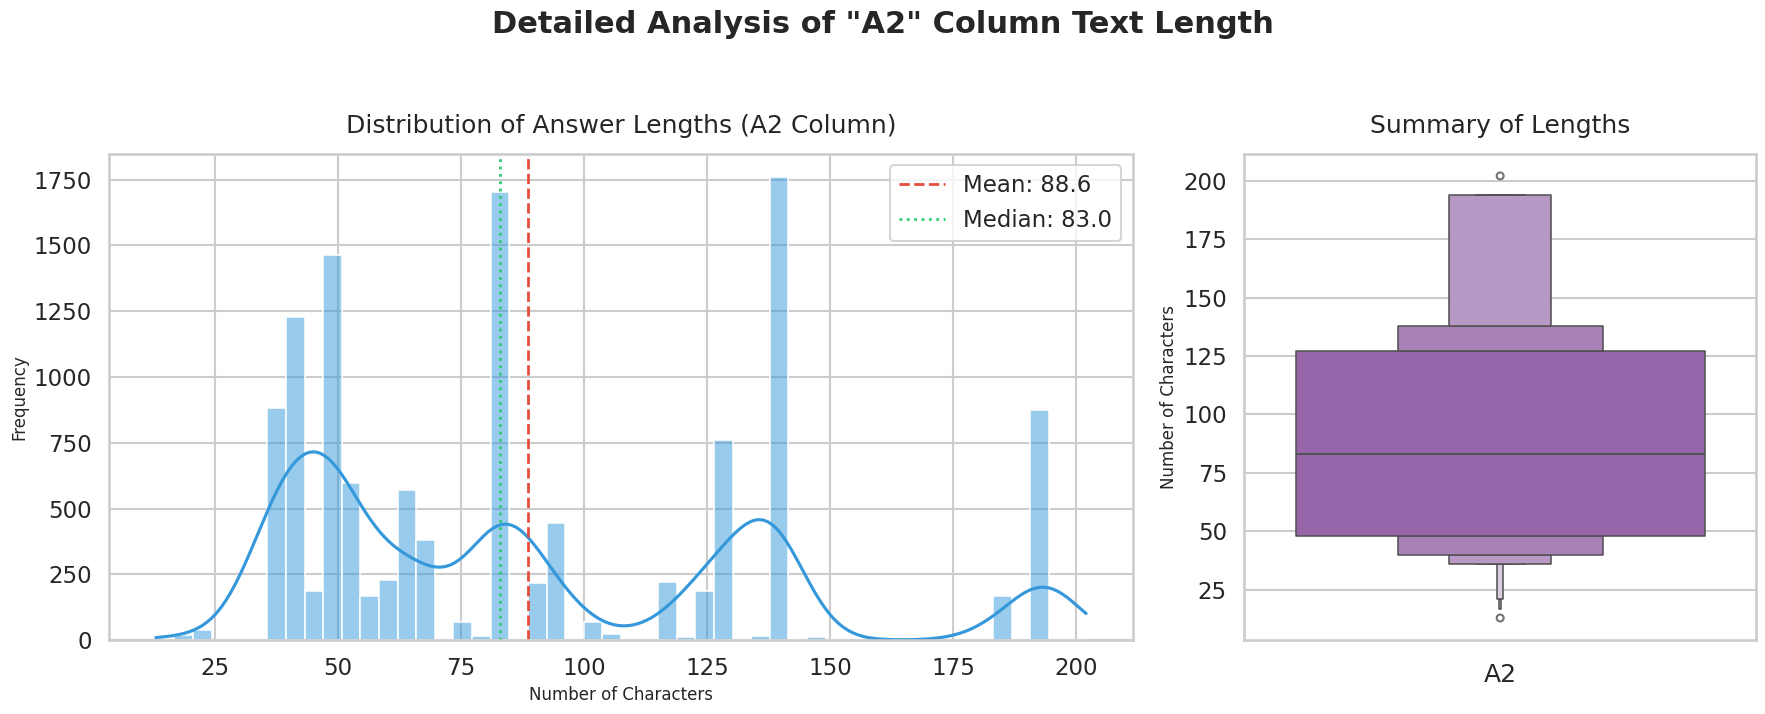

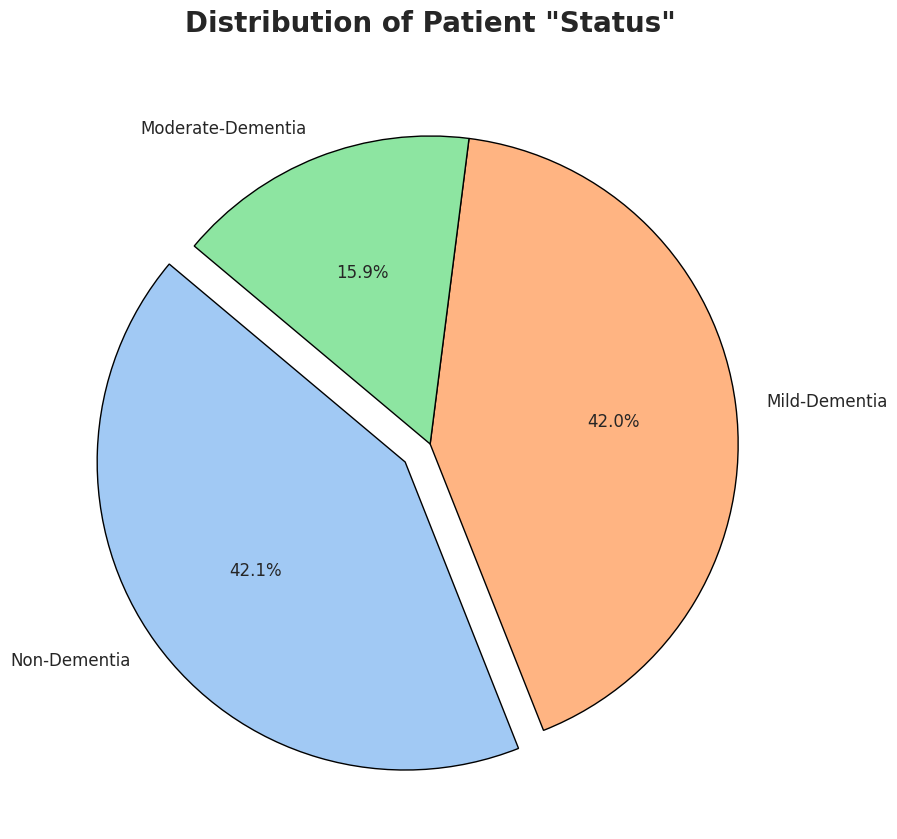

In [ ]:
# --- Step 5: Visualizations (Enhanced and "Fancier" Version) ---
print("\n" + "="*50)
print(" " * 20 + "VISUALIZATIONS")
print("="*50)

# Set a nice style for all plots
sns.set_theme(style="whitegrid", context="talk")

# 1. Bar chart of unique value counts
if 'summary_df' in locals() and not summary_df.empty:
    unique_counts_df = summary_df[['Column', 'Unique Values']].sort_values('Unique Values', ascending=False)

    plt.figure(figsize=(14, 8))
    # Create the barplot with a nice color palette
    barplot = sns.barplot(
        x='Unique Values',
        y='Column',
        data=unique_counts_df,
        palette='magma_r', # A visually appealing color palette
        edgecolor='black',
        linewidth=1.5
    )

    # --- Add annotations (the actual numbers on the bars) ---
    for p in barplot.patches:
        width = p.get_width()
        plt.text(
            width * 1.05, # Position x: slightly to the right of the bar
            p.get_y() + p.get_height() / 2, # Position y: vertically centered
            f'{int(width)}', # The text to display (count as integer)
            va='center'
        )

    plt.title('Uniqueness of Q&A Columns', fontsize=20, pad=20, weight='bold')
    plt.xlabel('Number of Unique Entries (Log Scale)', fontsize=14)
    plt.ylabel('Column', fontsize=14)
    plt.xscale('log') # Log scale is good for wide-ranging values
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    # Add a bit of margin to the right to fit the annotations
    plt.xlim(right=unique_counts_df['Unique Values'].max() * 1.5)
    plt.tight_layout()
    plt.show()

# 2. Histogram and Boxenplot of text lengths for a key answer column (A2)
if 'A2' in df_for_analysis.columns:
    # Prepare the data
    char_lengths_a2 = df_for_analysis['A2'].dropna().astype(str).str.len()

    # Create a figure with two subplots side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [2, 1]})

    # --- Subplot 1: Histogram (Density Plot) ---
    sns.histplot(
        char_lengths_a2,
        bins=50,
        kde=True,
        ax=axes[0],
        color='#3498db' # A nice blue color
    )
    axes[0].set_title('Distribution of Answer Lengths (A2 Column)', fontsize=18, pad=15)
    axes[0].set_xlabel('Number of Characters', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].axvline(char_lengths_a2.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {char_lengths_a2.mean():.1f}')
    axes[0].axvline(char_lengths_a2.median(), color='#2ecc71', linestyle=':', linewidth=2, label=f'Median: {char_lengths_a2.median():.1f}')
    axes[0].legend()

    # --- Subplot 2: Boxenplot (Enhanced Box Plot) ---
    sns.boxenplot(y=char_lengths_a2, ax=axes[1], color='#9b59b6') # A nice purple color
    axes[1].set_title('Summary of Lengths', fontsize=18, pad=15)
    axes[1].set_ylabel('Number of Characters', fontsize=12)
    axes[1].set_xlabel('A2')

    plt.suptitle('Detailed Analysis of "A2" Column Text Length', fontsize=22, weight='bold', y=1.03)
    plt.tight_layout()
    plt.show()

# 3. Pie chart for 'Status' column distribution
if 'Status' in df_for_analysis.columns:
    status_counts = df_for_analysis['Status'].value_counts()

    # Use a visually distinct color palette
    colors = sns.color_palette('pastel')[0:len(status_counts)]

    plt.figure(figsize=(10, 10))
    # Explode the largest slice slightly for emphasis
    explode = [0.1] + [0] * (len(status_counts) - 1)

    plt.pie(
        status_counts,
        labels=status_counts.index,
        autopct='%1.1f%%', # Format for percentages
        startangle=140,
        colors=colors,
        explode=explode,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1},
        textprops={'fontsize': 12}
    )
    plt.title('Distribution of Patient "Status"', fontsize=20, pad=20, weight='bold')
    plt.ylabel('') # Hide the 'Status' label on the y-axis for a cleaner look
    plt.show()

# Arabic

Loading the 'Arabic' subset from the 'tungvu3196/vlm-projects-multi-lang-final' dataset...
Dataset subset loaded successfully.
Loading dataset: tungvu3196/vlm-projects-multi-lang-final...


data/arabic/train.parquet:   0%|          | 0.00/1.87G [00:00<?, ?B/s]

data/arabic/test.parquet:   0%|          | 0.00/261M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10783 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1542 [00:00<?, ? examples/s]

Dataset loaded successfully.

Combining all splits for a global analysis...

Converting to pandas DataFrame for analysis (this may take a moment)...
Analysis will be performed on 12325 total rows.


Analyzing columns:   0%|          | 0/8 [00:00<?, ?it/s]


--- Analysis for column: 'Q1' ---
  Completeness:
    - Total Rows: 12325
    - Non-Empty Entries: 12325 (100.0%)
    - Missing/Empty Entries: 0 (0.0%)
  Uniqueness: 31 unique values
  Text Length (for non-empty values):
    - Characters: Min=16, Avg=21.7, Max=31
    - Words: Min=3, Avg=3.8, Max=5
  Top 5 Most Common Values:
    - "تحديد منطقة المرض..." : 1683 times (13.7%)
    - "التعرف على منطقة المرض..." : 1432 times (11.6%)
    - "وضع علامة على منطقة المرض..." : 941 times (7.6%)
    - "تسليط الضوء على موقع المرض..." : 783 times (6.4%)
    - "تسليط الضوء على البقعة المتأثرة..." : 612 times (5.0%)

--- Analysis for column: 'A1' ---
  Completeness:
    - Total Rows: 12325
    - Non-Empty Entries: 12325 (100.0%)
    - Missing/Empty Entries: 0 (0.0%)
  Uniqueness: 12197 unique values
  Text Length (for non-empty values):
    - Characters: Min=24, Avg=266.6, Max=661
    - Words: Min=4, Avg=12.9, Max=32
  A1 Specific (Bounding Boxes):
    - Avg Boxes per Entry: 3.23
    - Max Boxes per E

/tmp/ipython-input-3849814548.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


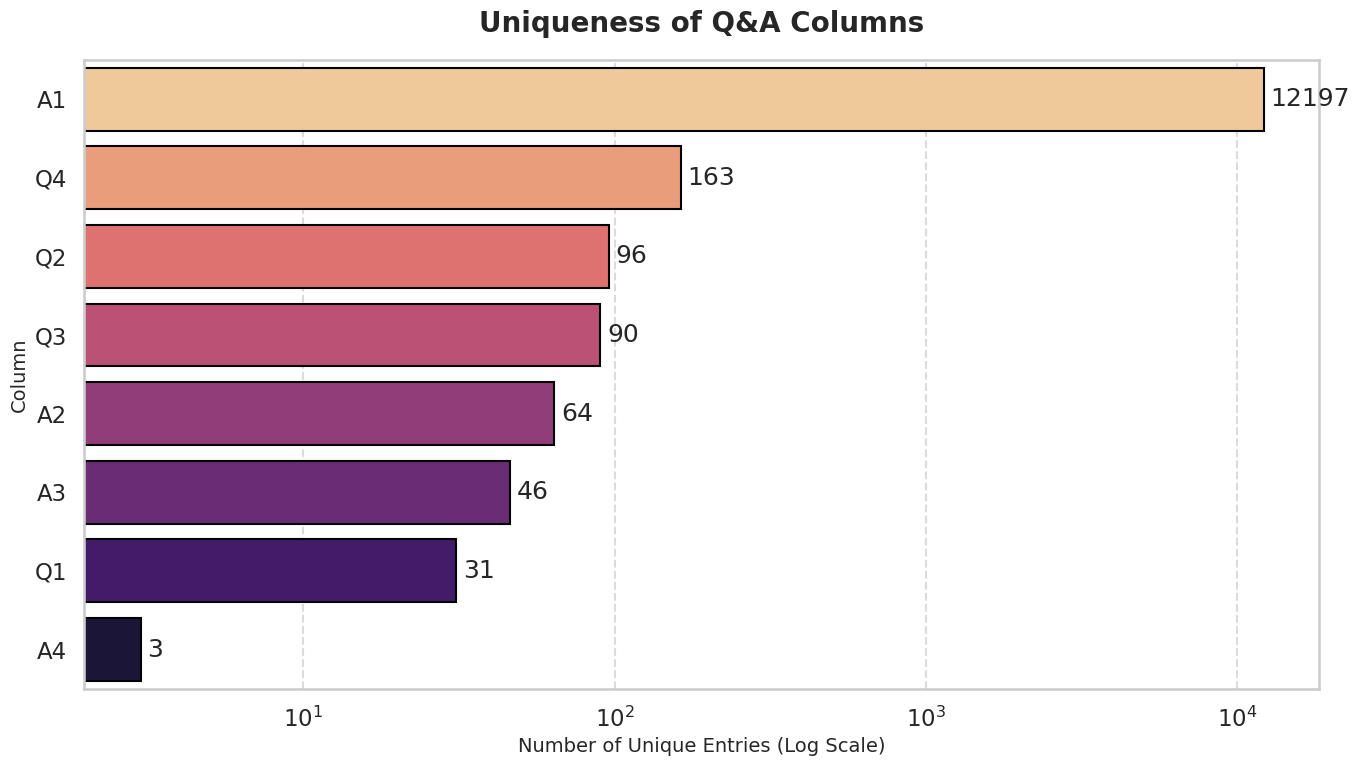

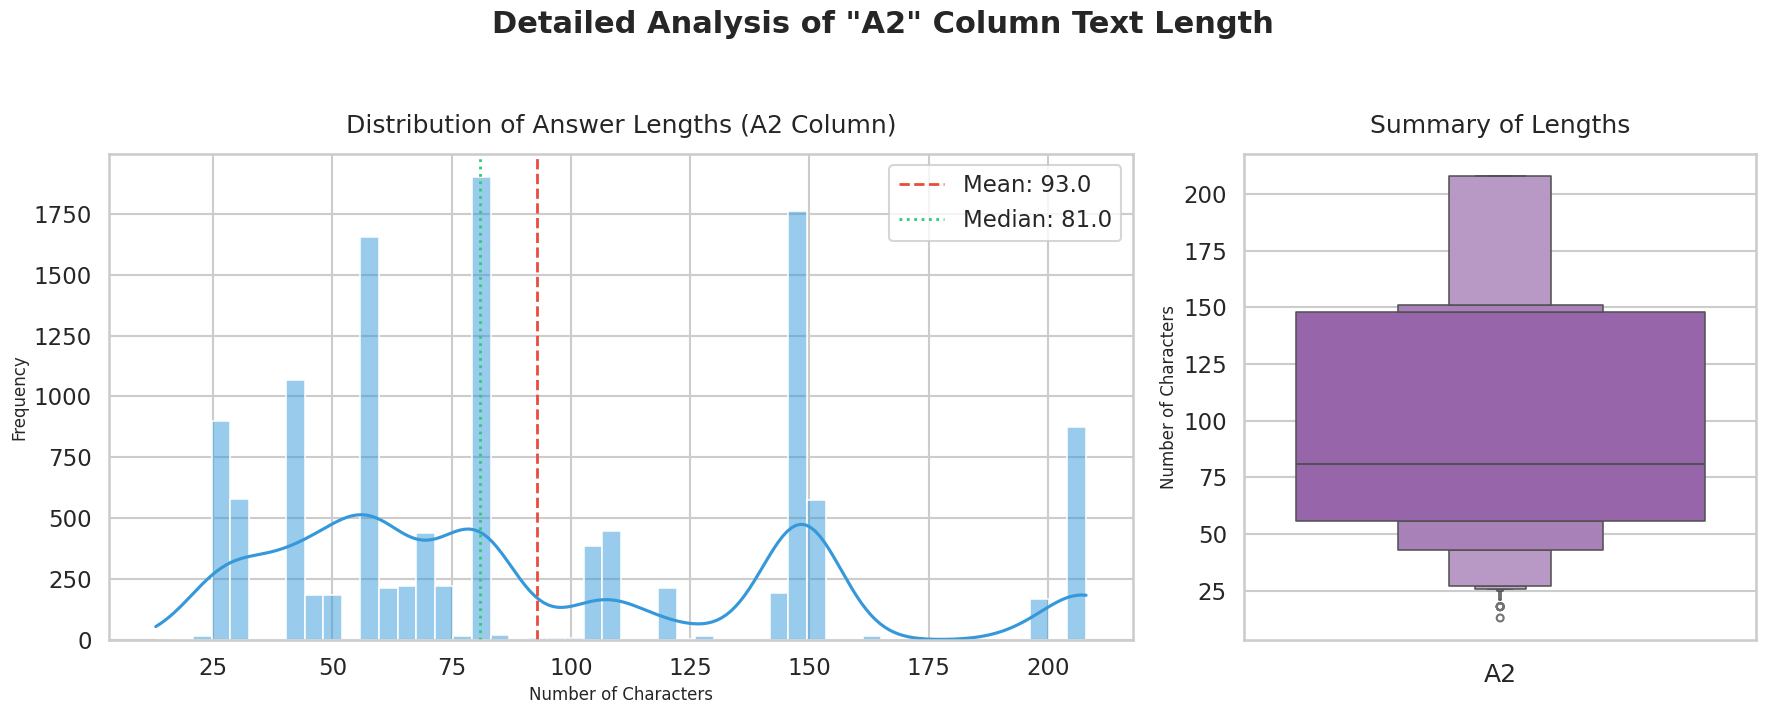

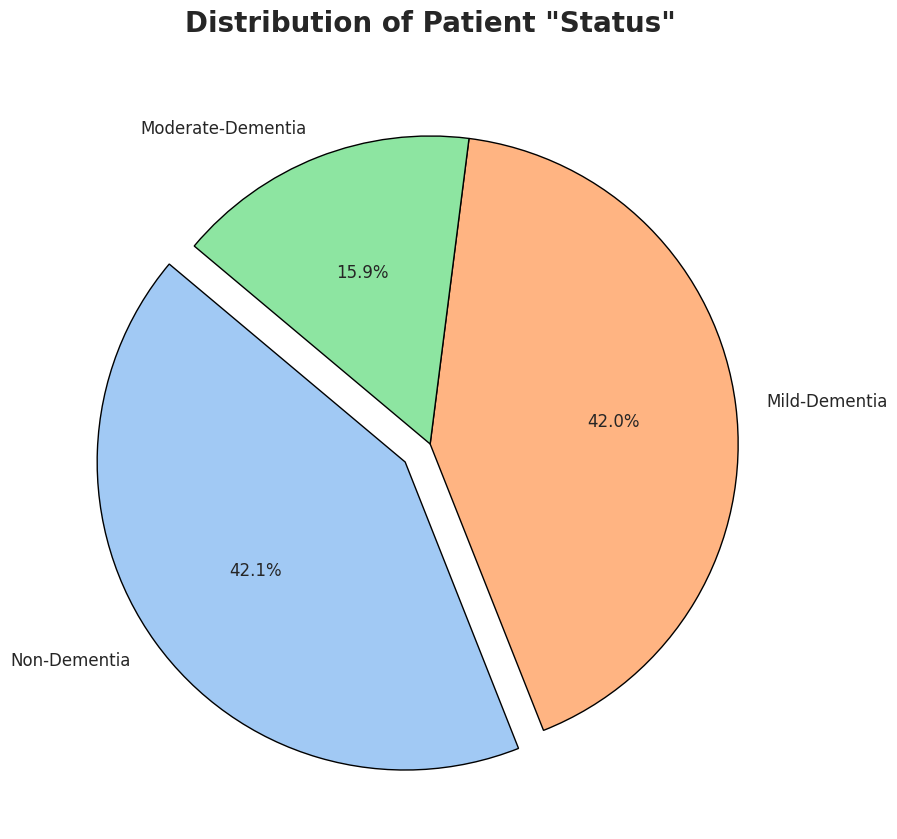

In [ ]:
!pip install -q datasets pandas matplotlib seaborn

from datasets import load_dataset, concatenate_datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
from tqdm.auto import tqdm # For progress bars

# --- Configuration ---
HF_DATASET_NAME = "tungvu3196/vlm-projects-multi-lang-final"
subset_name = "Arabic"

# 2. Load the specific 'Vietnamese' subset of the dataset
print(f"Loading the '{subset_name}' subset from the '{HF_DATASET_NAME}' dataset...")
# dataset_subset = load_dataset(HF_DATASET_NAME, name=subset_name)
print("Dataset subset loaded successfully.")
FOCUS_COLUMNS = ['Q1', 'A1', 'Q2', 'A2', 'Q3', 'A3', 'Q4', 'A4']

# --- Step 1: Load and Prepare the Dataset ---
print(f"Loading dataset: {HF_DATASET_NAME}...")
try:
    hf_dataset_dict = load_dataset(HF_DATASET_NAME, name=subset_name)
    print("Dataset loaded successfully.")

    all_splits_list = [split for name, split in hf_dataset_dict.items()]
    if not all_splits_list: raise ValueError("No data splits found.")

    print("\nCombining all splits for a global analysis...")
    combined_dataset = concatenate_datasets(all_splits_list)

    print("\nConverting to pandas DataFrame for analysis (this may take a moment)...")
    df_for_analysis = combined_dataset.to_pandas()
    print(f"Analysis will be performed on {len(df_for_analysis)} total rows.")

except Exception as e:
    print(f"An error occurred: {e}"); exit()


# --- Step 2: Define Analysis Function ---
def analyze_column(df, column_name):
    """Performs a detailed statistical analysis on a specific DataFrame column."""

    # Ensure the column exists
    if column_name not in df.columns:
        print(f"\n--- Analysis for column: '{column_name}' ---")
        print("  Column not found in dataset. Skipping.")
        return None

    print(f"\n--- Analysis for column: '{column_name}' ---")

    stats = {}
    col_series = df[column_name]

    # 1. Completeness
    total_entries = len(col_series)
    # Treat None, NaN, and empty/whitespace-only strings as "missing"
    non_empty_series = col_series.dropna().astype(str).str.strip()
    non_empty_count = non_empty_series[non_empty_series != ''].count()
    missing_count = total_entries - non_empty_count

    stats['Total Rows'] = total_entries
    stats['Non-Empty'] = f"{non_empty_count} ({non_empty_count / total_entries:.1%})"
    stats['Missing/Empty'] = f"{missing_count} ({missing_count / total_entries:.1%})"

    print(f"  Completeness:")
    print(f"    - Total Rows: {stats['Total Rows']}")
    print(f"    - Non-Empty Entries: {stats['Non-Empty']}")
    print(f"    - Missing/Empty Entries: {stats['Missing/Empty']}")

    # 2. Uniqueness
    unique_count = non_empty_series[non_empty_series != ''].nunique()
    stats['Unique Values'] = unique_count
    print(f"  Uniqueness: {unique_count} unique values")

    # 3. Length Analysis (for non-empty strings)
    if non_empty_count > 0:
        char_lengths = non_empty_series[non_empty_series != ''].str.len()
        word_counts = non_empty_series[non_empty_series != ''].str.split().str.len()

        stats['Min Chars'] = int(char_lengths.min())
        stats['Avg Chars'] = f"{char_lengths.mean():.1f}"
        stats['Max Chars'] = int(char_lengths.max())

        stats['Min Words'] = int(word_counts.min())
        stats['Avg Words'] = f"{word_counts.mean():.1f}"
        stats['Max Words'] = int(word_counts.max())

        print("  Text Length (for non-empty values):")
        print(f"    - Characters: Min={stats['Min Chars']}, Avg={stats['Avg Chars']}, Max={stats['Max Chars']}")
        print(f"    - Words: Min={stats['Min Words']}, Avg={stats['Avg Words']}, Max={stats['Max Words']}")

        # 4. Special Analysis for A1 (Bbox count)
        if column_name == 'A1':
            def count_bboxes(bbox_str):
                try:
                    parsed = ast.literal_eval(bbox_str)
                    if isinstance(parsed, list):
                        # Handle nesting like [[...]]
                        if len(parsed) > 0 and isinstance(parsed[0], list):
                            return len(parsed)
                except (ValueError, SyntaxError):
                    return 0 # Not a valid list representation
                return 0

            bbox_counts = non_empty_series[non_empty_series != ''].apply(count_bboxes)
            stats['Avg BBoxes/Entry'] = f"{bbox_counts.mean():.2f}"
            stats['Max BBoxes/Entry'] = int(bbox_counts.max())
            print("  A1 Specific (Bounding Boxes):")
            print(f"    - Avg Boxes per Entry: {stats['Avg BBoxes/Entry']}")
            print(f"    - Max Boxes per Entry: {stats['Max BBoxes/Entry']}")

    # 5. Value Distribution
    print("  Top 5 Most Common Values:")
    if non_empty_count > 0:
        top_5 = non_empty_series[non_empty_series != ''].value_counts().head(5)
        for value, count in top_5.items():
            percentage = count / non_empty_count * 100
            print(f"    - \"{str(value)[:70]}...\" : {count} times ({percentage:.1f}%)")
    else:
        print("    - No values to display.")

    return {column_name: stats}


# --- Step 3: Run Analysis for All Focus Columns ---
all_stats = {}
column_stats_list = []

for column in tqdm(FOCUS_COLUMNS, desc="Analyzing columns"):
    stats_result = analyze_column(df_for_analysis, column)
    if stats_result:
        # For the summary table
        col_stats_for_df = stats_result[column]
        col_stats_for_df['Column'] = column
        column_stats_list.append(col_stats_for_df)
        # For the main dict
        all_stats.update(stats_result)

# --- Step 4: Display Summary Table ---
print("\n" + "="*50)
print(" " * 15 + "DATASET STATISTICS SUMMARY")
print("="*50)

if column_stats_list:
    summary_df = pd.DataFrame(column_stats_list)
    # Reorder columns for clarity
    summary_order = [
        'Column', 'Non-Empty', 'Missing/Empty', 'Unique Values',
        'Avg Chars', 'Min Chars', 'Max Chars', 'Avg Words'
    ]
    # Add A1-specific columns if they exist
    if 'Avg BBoxes/Entry' in summary_df.columns:
        summary_order.extend(['Avg BBoxes/Entry', 'Max BBoxes/Entry'])

    # Filter for columns that actually exist in the summary df
    final_summary_order = [col for col in summary_order if col in summary_df.columns]
    summary_df = summary_df[final_summary_order]

    print(summary_df.to_string(index=False))
else:
    print("No statistics were generated.")
print("="*50)


# --- Step 5: Visualizations ---
# --- Step 5: Visualizations (Enhanced and "Fancier" Version) ---
print("\n" + "="*50)
print(" " * 20 + "VISUALIZATIONS")
print("="*50)

# Set a nice style for all plots
sns.set_theme(style="whitegrid", context="talk")

# 1. Bar chart of unique value counts
if 'summary_df' in locals() and not summary_df.empty:
    unique_counts_df = summary_df[['Column', 'Unique Values']].sort_values('Unique Values', ascending=False)

    plt.figure(figsize=(14, 8))
    # Create the barplot with a nice color palette
    barplot = sns.barplot(
        x='Unique Values',
        y='Column',
        data=unique_counts_df,
        palette='magma_r', # A visually appealing color palette
        edgecolor='black',
        linewidth=1.5
    )

    # --- Add annotations (the actual numbers on the bars) ---
    for p in barplot.patches:
        width = p.get_width()
        plt.text(
            width * 1.05, # Position x: slightly to the right of the bar
            p.get_y() + p.get_height() / 2, # Position y: vertically centered
            f'{int(width)}', # The text to display (count as integer)
            va='center'
        )

    plt.title('Uniqueness of Q&A Columns', fontsize=20, pad=20, weight='bold')
    plt.xlabel('Number of Unique Entries (Log Scale)', fontsize=14)
    plt.ylabel('Column', fontsize=14)
    plt.xscale('log') # Log scale is good for wide-ranging values
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    # Add a bit of margin to the right to fit the annotations
    plt.xlim(right=unique_counts_df['Unique Values'].max() * 1.5)
    plt.tight_layout()
    plt.show()

# 2. Histogram and Boxenplot of text lengths for a key answer column (A2)
if 'A2' in df_for_analysis.columns:
    # Prepare the data
    char_lengths_a2 = df_for_analysis['A2'].dropna().astype(str).str.len()

    # Create a figure with two subplots side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [2, 1]})

    # --- Subplot 1: Histogram (Density Plot) ---
    sns.histplot(
        char_lengths_a2,
        bins=50,
        kde=True,
        ax=axes[0],
        color='#3498db' # A nice blue color
    )
    axes[0].set_title('Distribution of Answer Lengths (A2 Column)', fontsize=18, pad=15)
    axes[0].set_xlabel('Number of Characters', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].axvline(char_lengths_a2.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {char_lengths_a2.mean():.1f}')
    axes[0].axvline(char_lengths_a2.median(), color='#2ecc71', linestyle=':', linewidth=2, label=f'Median: {char_lengths_a2.median():.1f}')
    axes[0].legend()

    # --- Subplot 2: Boxenplot (Enhanced Box Plot) ---
    sns.boxenplot(y=char_lengths_a2, ax=axes[1], color='#9b59b6') # A nice purple color
    axes[1].set_title('Summary of Lengths', fontsize=18, pad=15)
    axes[1].set_ylabel('Number of Characters', fontsize=12)
    axes[1].set_xlabel('A2')

    plt.suptitle('Detailed Analysis of "A2" Column Text Length', fontsize=22, weight='bold', y=1.03)
    plt.tight_layout()
    plt.show()

# 3. Pie chart for 'Status' column distribution
if 'Status' in df_for_analysis.columns:
    status_counts = df_for_analysis['Status'].value_counts()

    # Use a visually distinct color palette
    colors = sns.color_palette('pastel')[0:len(status_counts)]

    plt.figure(figsize=(10, 10))
    # Explode the largest slice slightly for emphasis
    explode = [0.1] + [0] * (len(status_counts) - 1)

    plt.pie(
        status_counts,
        labels=status_counts.index,
        autopct='%1.1f%%', # Format for percentages
        startangle=140,
        colors=colors,
        explode=explode,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1},
        textprops={'fontsize': 12}
    )
    plt.title('Distribution of Patient "Status"', fontsize=20, pad=20, weight='bold')
    plt.ylabel('') # Hide the 'Status' label on the y-axis for a cleaner look
    plt.show()

# English

Loading the 'French' subset from the 'tungvu3196/vlm-projects-multi-lang-final' dataset...
Dataset subset loaded successfully.
Loading dataset: tungvu3196/vlm-projects-multi-lang-final...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


data/french/train.parquet:   0%|          | 0.00/1.87G [00:00<?, ?B/s]

data/french/test.parquet:   0%|          | 0.00/261M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10783 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1542 [00:00<?, ? examples/s]

Dataset loaded successfully.

Combining all splits for a global analysis...

Converting to pandas DataFrame for analysis (this may take a moment)...
Analysis will be performed on 12325 total rows.


Analyzing columns:   0%|          | 0/8 [00:00<?, ?it/s]


--- Analysis for column: 'Q1' ---
  Completeness:
    - Total Rows: 12325
    - Non-Empty Entries: 12325 (100.0%)
    - Missing/Empty Entries: 0 (0.0%)
  Uniqueness: 27 unique values
  Text Length (for non-empty values):
    - Characters: Min=24, Avg=31.3, Max=42
    - Words: Min=4, Avg=4.5, Max=7
  Top 5 Most Common Values:
    - "Identifier la zone pathologique..." : 2971 times (24.1%)
    - "Mettre en évidence la zone pathologique..." : 987 times (8.0%)
    - "Marquer la zone pathologique..." : 941 times (7.6%)
    - "Définir la zone pathologique..." : 815 times (6.6%)
    - "Déterminer la zone pathologique..." : 722 times (5.9%)

--- Analysis for column: 'A1' ---
  Completeness:
    - Total Rows: 12325
    - Non-Empty Entries: 12325 (100.0%)
    - Missing/Empty Entries: 0 (0.0%)
  Uniqueness: 12197 unique values
  Text Length (for non-empty values):
    - Characters: Min=24, Avg=266.6, Max=661
    - Words: Min=4, Avg=12.9, Max=32
  A1 Specific (Bounding Boxes):
    - Avg Boxes per

/tmp/ipython-input-2608787575.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


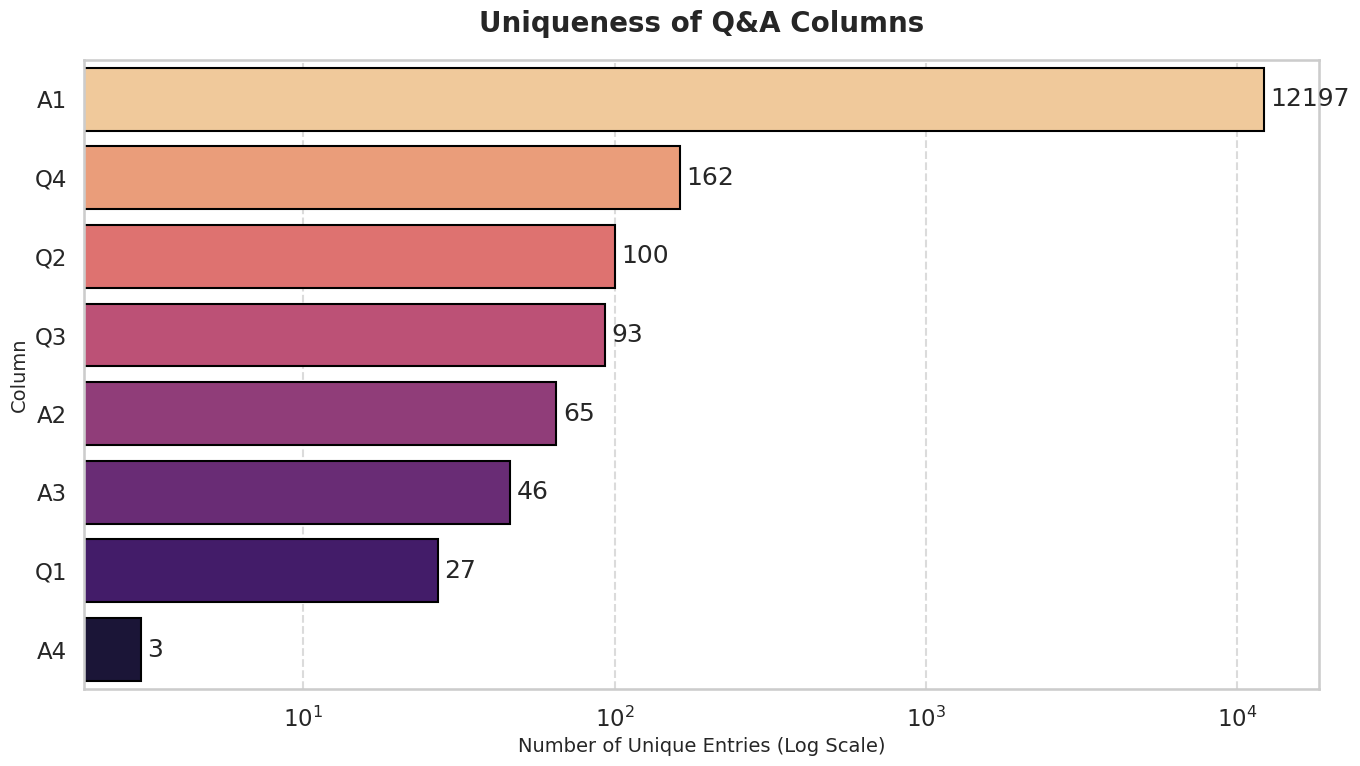

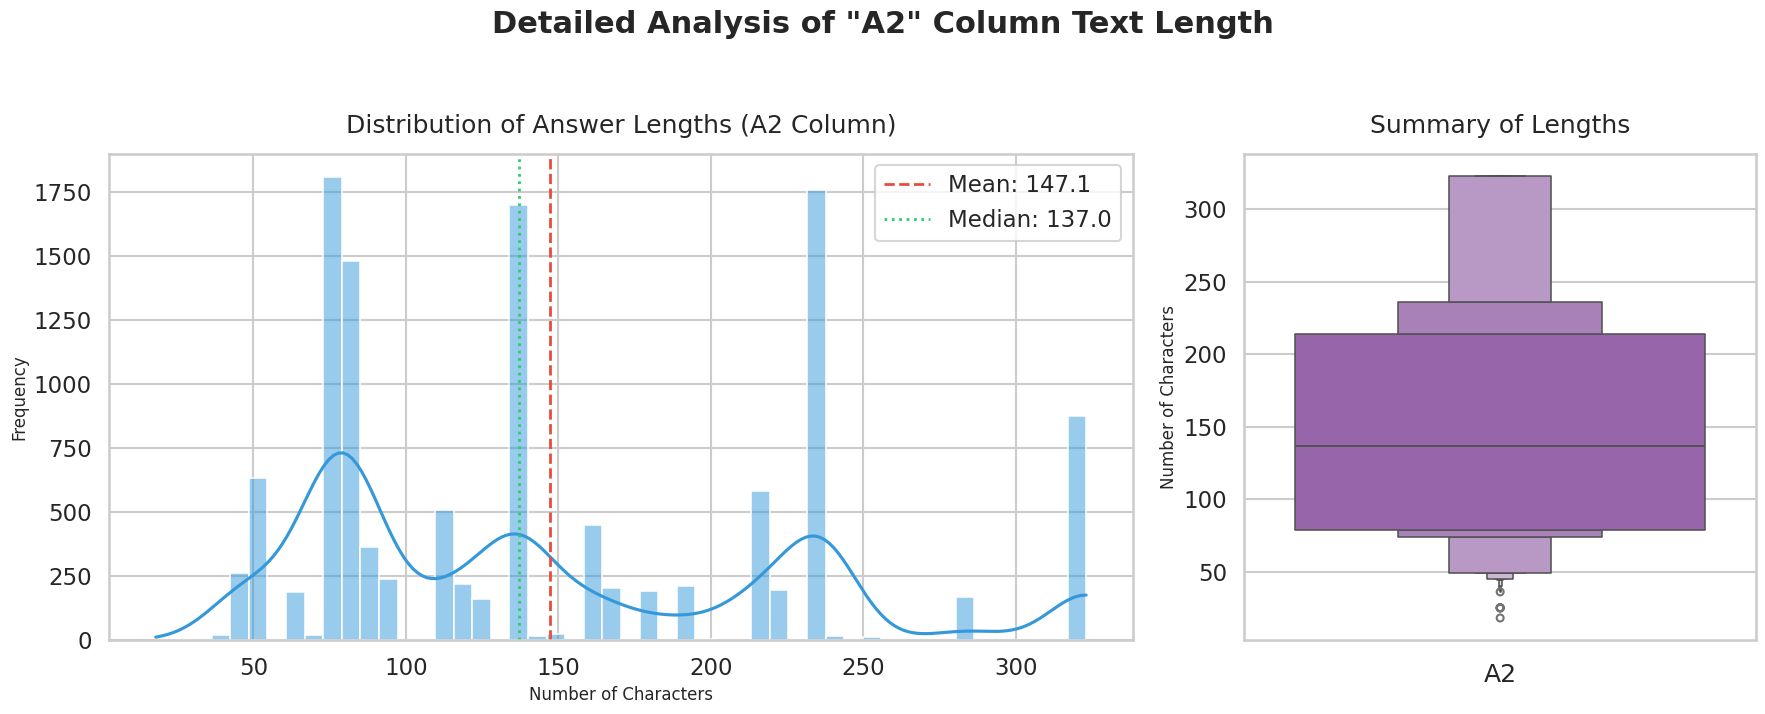

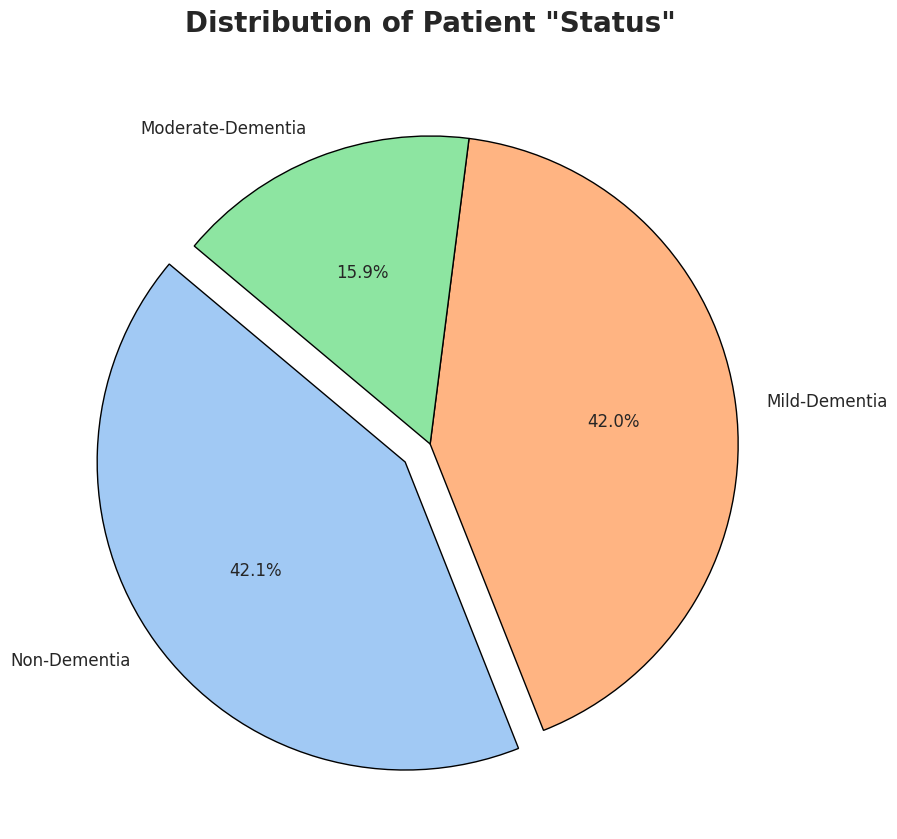

In [ ]:
!pip install -q datasets pandas matplotlib seaborn

from datasets import load_dataset, concatenate_datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
from tqdm.auto import tqdm # For progress bars

# --- Configuration ---
HF_DATASET_NAME = "tungvu3196/vlm-projects-multi-lang-final"
subset_name = "French"

# 2. Load the specific 'Vietnamese' subset of the dataset
print(f"Loading the '{subset_name}' subset from the '{HF_DATASET_NAME}' dataset...")
# dataset_subset = load_dataset(HF_DATASET_NAME, name=subset_name)
print("Dataset subset loaded successfully.")
FOCUS_COLUMNS = ['Q1', 'A1', 'Q2', 'A2', 'Q3', 'A3', 'Q4', 'A4']

# --- Step 1: Load and Prepare the Dataset ---
print(f"Loading dataset: {HF_DATASET_NAME}...")
try:
    hf_dataset_dict = load_dataset(HF_DATASET_NAME, name=subset_name)
    print("Dataset loaded successfully.")

    all_splits_list = [split for name, split in hf_dataset_dict.items()]
    if not all_splits_list: raise ValueError("No data splits found.")

    print("\nCombining all splits for a global analysis...")
    combined_dataset = concatenate_datasets(all_splits_list)

    print("\nConverting to pandas DataFrame for analysis (this may take a moment)...")
    df_for_analysis = combined_dataset.to_pandas()
    print(f"Analysis will be performed on {len(df_for_analysis)} total rows.")

except Exception as e:
    print(f"An error occurred: {e}"); exit()


# --- Step 2: Define Analysis Function ---
def analyze_column(df, column_name):
    """Performs a detailed statistical analysis on a specific DataFrame column."""

    # Ensure the column exists
    if column_name not in df.columns:
        print(f"\n--- Analysis for column: '{column_name}' ---")
        print("  Column not found in dataset. Skipping.")
        return None

    print(f"\n--- Analysis for column: '{column_name}' ---")

    stats = {}
    col_series = df[column_name]

    # 1. Completeness
    total_entries = len(col_series)
    # Treat None, NaN, and empty/whitespace-only strings as "missing"
    non_empty_series = col_series.dropna().astype(str).str.strip()
    non_empty_count = non_empty_series[non_empty_series != ''].count()
    missing_count = total_entries - non_empty_count

    stats['Total Rows'] = total_entries
    stats['Non-Empty'] = f"{non_empty_count} ({non_empty_count / total_entries:.1%})"
    stats['Missing/Empty'] = f"{missing_count} ({missing_count / total_entries:.1%})"

    print(f"  Completeness:")
    print(f"    - Total Rows: {stats['Total Rows']}")
    print(f"    - Non-Empty Entries: {stats['Non-Empty']}")
    print(f"    - Missing/Empty Entries: {stats['Missing/Empty']}")

    # 2. Uniqueness
    unique_count = non_empty_series[non_empty_series != ''].nunique()
    stats['Unique Values'] = unique_count
    print(f"  Uniqueness: {unique_count} unique values")

    # 3. Length Analysis (for non-empty strings)
    if non_empty_count > 0:
        char_lengths = non_empty_series[non_empty_series != ''].str.len()
        word_counts = non_empty_series[non_empty_series != ''].str.split().str.len()

        stats['Min Chars'] = int(char_lengths.min())
        stats['Avg Chars'] = f"{char_lengths.mean():.1f}"
        stats['Max Chars'] = int(char_lengths.max())

        stats['Min Words'] = int(word_counts.min())
        stats['Avg Words'] = f"{word_counts.mean():.1f}"
        stats['Max Words'] = int(word_counts.max())

        print("  Text Length (for non-empty values):")
        print(f"    - Characters: Min={stats['Min Chars']}, Avg={stats['Avg Chars']}, Max={stats['Max Chars']}")
        print(f"    - Words: Min={stats['Min Words']}, Avg={stats['Avg Words']}, Max={stats['Max Words']}")

        # 4. Special Analysis for A1 (Bbox count)
        if column_name == 'A1':
            def count_bboxes(bbox_str):
                try:
                    parsed = ast.literal_eval(bbox_str)
                    if isinstance(parsed, list):
                        # Handle nesting like [[...]]
                        if len(parsed) > 0 and isinstance(parsed[0], list):
                            return len(parsed)
                except (ValueError, SyntaxError):
                    return 0 # Not a valid list representation
                return 0

            bbox_counts = non_empty_series[non_empty_series != ''].apply(count_bboxes)
            stats['Avg BBoxes/Entry'] = f"{bbox_counts.mean():.2f}"
            stats['Max BBoxes/Entry'] = int(bbox_counts.max())
            print("  A1 Specific (Bounding Boxes):")
            print(f"    - Avg Boxes per Entry: {stats['Avg BBoxes/Entry']}")
            print(f"    - Max Boxes per Entry: {stats['Max BBoxes/Entry']}")

    # 5. Value Distribution
    print("  Top 5 Most Common Values:")
    if non_empty_count > 0:
        top_5 = non_empty_series[non_empty_series != ''].value_counts().head(5)
        for value, count in top_5.items():
            percentage = count / non_empty_count * 100
            print(f"    - \"{str(value)[:70]}...\" : {count} times ({percentage:.1f}%)")
    else:
        print("    - No values to display.")

    return {column_name: stats}


# --- Step 3: Run Analysis for All Focus Columns ---
all_stats = {}
column_stats_list = []

for column in tqdm(FOCUS_COLUMNS, desc="Analyzing columns"):
    stats_result = analyze_column(df_for_analysis, column)
    if stats_result:
        # For the summary table
        col_stats_for_df = stats_result[column]
        col_stats_for_df['Column'] = column
        column_stats_list.append(col_stats_for_df)
        # For the main dict
        all_stats.update(stats_result)

# --- Step 4: Display Summary Table ---
print("\n" + "="*50)
print(" " * 15 + "DATASET STATISTICS SUMMARY")
print("="*50)

if column_stats_list:
    summary_df = pd.DataFrame(column_stats_list)
    # Reorder columns for clarity
    summary_order = [
        'Column', 'Non-Empty', 'Missing/Empty', 'Unique Values',
        'Avg Chars', 'Min Chars', 'Max Chars', 'Avg Words'
    ]
    # Add A1-specific columns if they exist
    if 'Avg BBoxes/Entry' in summary_df.columns:
        summary_order.extend(['Avg BBoxes/Entry', 'Max BBoxes/Entry'])

    # Filter for columns that actually exist in the summary df
    final_summary_order = [col for col in summary_order if col in summary_df.columns]
    summary_df = summary_df[final_summary_order]

    print(summary_df.to_string(index=False))
else:
    print("No statistics were generated.")
print("="*50)


# --- Step 5: Visualizations ---
# --- Step 5: Visualizations (Enhanced and "Fancier" Version) ---
print("\n" + "="*50)
print(" " * 20 + "VISUALIZATIONS")
print("="*50)

# Set a nice style for all plots
sns.set_theme(style="whitegrid", context="talk")

# 1. Bar chart of unique value counts
if 'summary_df' in locals() and not summary_df.empty:
    unique_counts_df = summary_df[['Column', 'Unique Values']].sort_values('Unique Values', ascending=False)

    plt.figure(figsize=(14, 8))
    # Create the barplot with a nice color palette
    barplot = sns.barplot(
        x='Unique Values',
        y='Column',
        data=unique_counts_df,
        palette='magma_r', # A visually appealing color palette
        edgecolor='black',
        linewidth=1.5
    )

    # --- Add annotations (the actual numbers on the bars) ---
    for p in barplot.patches:
        width = p.get_width()
        plt.text(
            width * 1.05, # Position x: slightly to the right of the bar
            p.get_y() + p.get_height() / 2, # Position y: vertically centered
            f'{int(width)}', # The text to display (count as integer)
            va='center'
        )

    plt.title('Uniqueness of Q&A Columns', fontsize=20, pad=20, weight='bold')
    plt.xlabel('Number of Unique Entries (Log Scale)', fontsize=14)
    plt.ylabel('Column', fontsize=14)
    plt.xscale('log') # Log scale is good for wide-ranging values
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    # Add a bit of margin to the right to fit the annotations
    plt.xlim(right=unique_counts_df['Unique Values'].max() * 1.5)
    plt.tight_layout()
    plt.show()

# 2. Histogram and Boxenplot of text lengths for a key answer column (A2)
if 'A2' in df_for_analysis.columns:
    # Prepare the data
    char_lengths_a2 = df_for_analysis['A2'].dropna().astype(str).str.len()

    # Create a figure with two subplots side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [2, 1]})

    # --- Subplot 1: Histogram (Density Plot) ---
    sns.histplot(
        char_lengths_a2,
        bins=50,
        kde=True,
        ax=axes[0],
        color='#3498db' # A nice blue color
    )
    axes[0].set_title('Distribution of Answer Lengths (A2 Column)', fontsize=18, pad=15)
    axes[0].set_xlabel('Number of Characters', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].axvline(char_lengths_a2.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {char_lengths_a2.mean():.1f}')
    axes[0].axvline(char_lengths_a2.median(), color='#2ecc71', linestyle=':', linewidth=2, label=f'Median: {char_lengths_a2.median():.1f}')
    axes[0].legend()

    # --- Subplot 2: Boxenplot (Enhanced Box Plot) ---
    sns.boxenplot(y=char_lengths_a2, ax=axes[1], color='#9b59b6') # A nice purple color
    axes[1].set_title('Summary of Lengths', fontsize=18, pad=15)
    axes[1].set_ylabel('Number of Characters', fontsize=12)
    axes[1].set_xlabel('A2')

    plt.suptitle('Detailed Analysis of "A2" Column Text Length', fontsize=22, weight='bold', y=1.03)
    plt.tight_layout()
    plt.show()

# 3. Pie chart for 'Status' column distribution
if 'Status' in df_for_analysis.columns:
    status_counts = df_for_analysis['Status'].value_counts()

    # Use a visually distinct color palette
    colors = sns.color_palette('pastel')[0:len(status_counts)]

    plt.figure(figsize=(10, 10))
    # Explode the largest slice slightly for emphasis
    explode = [0.1] + [0] * (len(status_counts) - 1)

    plt.pie(
        status_counts,
        labels=status_counts.index,
        autopct='%1.1f%%', # Format for percentages
        startangle=140,
        colors=colors,
        explode=explode,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1},
        textprops={'fontsize': 12}
    )
    plt.title('Distribution of Patient "Status"', fontsize=20, pad=20, weight='bold')
    plt.ylabel('') # Hide the 'Status' label on the y-axis for a cleaner look
    plt.show()

# French

In [ ]:
!pip install -q datasets pandas matplotlib seaborn

from datasets import load_dataset, concatenate_datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
from tqdm.auto import tqdm # For progress bars

# --- Configuration ---
HF_DATASET_NAME = "tungvu3196/vlm-projects-multi-lang-final"
subset_name = "French"

# 2. Load the specific 'Vietnamese' subset of the dataset
print(f"Loading the '{subset_name}' subset from the '{HF_DATASET_NAME}' dataset...")
# dataset_subset = load_dataset(HF_DATASET_NAME, name=subset_name)
print("Dataset subset loaded successfully.")
FOCUS_COLUMNS = ['Q1', 'A1', 'Q2', 'A2', 'Q3', 'A3', 'Q4', 'A4']

# --- Step 1: Load and Prepare the Dataset ---
print(f"Loading dataset: {HF_DATASET_NAME}...")
try:
    hf_dataset_dict = load_dataset(HF_DATASET_NAME, name=subset_name)
    print("Dataset loaded successfully.")

    all_splits_list = [split for name, split in hf_dataset_dict.items()]
    if not all_splits_list: raise ValueError("No data splits found.")

    print("\nCombining all splits for a global analysis...")
    combined_dataset = concatenate_datasets(all_splits_list)

    print("\nConverting to pandas DataFrame for analysis (this may take a moment)...")
    df_for_analysis = combined_dataset.to_pandas()
    print(f"Analysis will be performed on {len(df_for_analysis)} total rows.")

except Exception as e:
    print(f"An error occurred: {e}"); exit()


# --- Step 2: Define Analysis Function ---
def analyze_column(df, column_name):
    """Performs a detailed statistical analysis on a specific DataFrame column."""

    # Ensure the column exists
    if column_name not in df.columns:
        print(f"\n--- Analysis for column: '{column_name}' ---")
        print("  Column not found in dataset. Skipping.")
        return None

    print(f"\n--- Analysis for column: '{column_name}' ---")

    stats = {}
    col_series = df[column_name]

    # 1. Completeness
    total_entries = len(col_series)
    # Treat None, NaN, and empty/whitespace-only strings as "missing"
    non_empty_series = col_series.dropna().astype(str).str.strip()
    non_empty_count = non_empty_series[non_empty_series != ''].count()
    missing_count = total_entries - non_empty_count

    stats['Total Rows'] = total_entries
    stats['Non-Empty'] = f"{non_empty_count} ({non_empty_count / total_entries:.1%})"
    stats['Missing/Empty'] = f"{missing_count} ({missing_count / total_entries:.1%})"

    print(f"  Completeness:")
    print(f"    - Total Rows: {stats['Total Rows']}")
    print(f"    - Non-Empty Entries: {stats['Non-Empty']}")
    print(f"    - Missing/Empty Entries: {stats['Missing/Empty']}")

    # 2. Uniqueness
    unique_count = non_empty_series[non_empty_series != ''].nunique()
    stats['Unique Values'] = unique_count
    print(f"  Uniqueness: {unique_count} unique values")

    # 3. Length Analysis (for non-empty strings)
    if non_empty_count > 0:
        char_lengths = non_empty_series[non_empty_series != ''].str.len()
        word_counts = non_empty_series[non_empty_series != ''].str.split().str.len()

        stats['Min Chars'] = int(char_lengths.min())
        stats['Avg Chars'] = f"{char_lengths.mean():.1f}"
        stats['Max Chars'] = int(char_lengths.max())

        stats['Min Words'] = int(word_counts.min())
        stats['Avg Words'] = f"{word_counts.mean():.1f}"
        stats['Max Words'] = int(word_counts.max())

        print("  Text Length (for non-empty values):")
        print(f"    - Characters: Min={stats['Min Chars']}, Avg={stats['Avg Chars']}, Max={stats['Max Chars']}")
        print(f"    - Words: Min={stats['Min Words']}, Avg={stats['Avg Words']}, Max={stats['Max Words']}")

        # 4. Special Analysis for A1 (Bbox count)
        if column_name == 'A1':
            def count_bboxes(bbox_str):
                try:
                    parsed = ast.literal_eval(bbox_str)
                    if isinstance(parsed, list):
                        # Handle nesting like [[...]]
                        if len(parsed) > 0 and isinstance(parsed[0], list):
                            return len(parsed)
                except (ValueError, SyntaxError):
                    return 0 # Not a valid list representation
                return 0

            bbox_counts = non_empty_series[non_empty_series != ''].apply(count_bboxes)
            stats['Avg BBoxes/Entry'] = f"{bbox_counts.mean():.2f}"
            stats['Max BBoxes/Entry'] = int(bbox_counts.max())
            print("  A1 Specific (Bounding Boxes):")
            print(f"    - Avg Boxes per Entry: {stats['Avg BBoxes/Entry']}")
            print(f"    - Max Boxes per Entry: {stats['Max BBoxes/Entry']}")

    # 5. Value Distribution
    print("  Top 5 Most Common Values:")
    if non_empty_count > 0:
        top_5 = non_empty_series[non_empty_series != ''].value_counts().head(5)
        for value, count in top_5.items():
            percentage = count / non_empty_count * 100
            print(f"    - \"{str(value)[:70]}...\" : {count} times ({percentage:.1f}%)")
    else:
        print("    - No values to display.")

    return {column_name: stats}


# --- Step 3: Run Analysis for All Focus Columns ---
all_stats = {}
column_stats_list = []

for column in tqdm(FOCUS_COLUMNS, desc="Analyzing columns"):
    stats_result = analyze_column(df_for_analysis, column)
    if stats_result:
        # For the summary table
        col_stats_for_df = stats_result[column]
        col_stats_for_df['Column'] = column
        column_stats_list.append(col_stats_for_df)
        # For the main dict
        all_stats.update(stats_result)

# --- Step 4: Display Summary Table ---
print("\n" + "="*50)
print(" " * 15 + "DATASET STATISTICS SUMMARY")
print("="*50)

if column_stats_list:
    summary_df = pd.DataFrame(column_stats_list)
    # Reorder columns for clarity
    summary_order = [
        'Column', 'Non-Empty', 'Missing/Empty', 'Unique Values',
        'Avg Chars', 'Min Chars', 'Max Chars', 'Avg Words'
    ]
    # Add A1-specific columns if they exist
    if 'Avg BBoxes/Entry' in summary_df.columns:
        summary_order.extend(['Avg BBoxes/Entry', 'Max BBoxes/Entry'])

    # Filter for columns that actually exist in the summary df
    final_summary_order = [col for col in summary_order if col in summary_df.columns]
    summary_df = summary_df[final_summary_order]

    print(summary_df.to_string(index=False))
else:
    print("No statistics were generated.")
print("="*50)


# --- Step 5: Visualizations ---
# --- Step 5: Visualizations (Enhanced and "Fancier" Version) ---
print("\n" + "="*50)
print(" " * 20 + "VISUALIZATIONS")
print("="*50)

# Set a nice style for all plots
sns.set_theme(style="whitegrid", context="talk")

# 1. Bar chart of unique value counts
if 'summary_df' in locals() and not summary_df.empty:
    unique_counts_df = summary_df[['Column', 'Unique Values']].sort_values('Unique Values', ascending=False)

    plt.figure(figsize=(14, 8))
    # Create the barplot with a nice color palette
    barplot = sns.barplot(
        x='Unique Values',
        y='Column',
        data=unique_counts_df,
        palette='magma_r', # A visually appealing color palette
        edgecolor='black',
        linewidth=1.5
    )

    # --- Add annotations (the actual numbers on the bars) ---
    for p in barplot.patches:
        width = p.get_width()
        plt.text(
            width * 1.05, # Position x: slightly to the right of the bar
            p.get_y() + p.get_height() / 2, # Position y: vertically centered
            f'{int(width)}', # The text to display (count as integer)
            va='center'
        )

    plt.title('Uniqueness of Q&A Columns', fontsize=20, pad=20, weight='bold')
    plt.xlabel('Number of Unique Entries (Log Scale)', fontsize=14)
    plt.ylabel('Column', fontsize=14)
    plt.xscale('log') # Log scale is good for wide-ranging values
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    # Add a bit of margin to the right to fit the annotations
    plt.xlim(right=unique_counts_df['Unique Values'].max() * 1.5)
    plt.tight_layout()
    plt.show()

# 2. Histogram and Boxenplot of text lengths for a key answer column (A2)
if 'A2' in df_for_analysis.columns:
    # Prepare the data
    char_lengths_a2 = df_for_analysis['A2'].dropna().astype(str).str.len()

    # Create a figure with two subplots side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [2, 1]})

    # --- Subplot 1: Histogram (Density Plot) ---
    sns.histplot(
        char_lengths_a2,
        bins=50,
        kde=True,
        ax=axes[0],
        color='#3498db' # A nice blue color
    )
    axes[0].set_title('Distribution of Answer Lengths (A2 Column)', fontsize=18, pad=15)
    axes[0].set_xlabel('Number of Characters', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].axvline(char_lengths_a2.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {char_lengths_a2.mean():.1f}')
    axes[0].axvline(char_lengths_a2.median(), color='#2ecc71', linestyle=':', linewidth=2, label=f'Median: {char_lengths_a2.median():.1f}')
    axes[0].legend()

    # --- Subplot 2: Boxenplot (Enhanced Box Plot) ---
    sns.boxenplot(y=char_lengths_a2, ax=axes[1], color='#9b59b6') # A nice purple color
    axes[1].set_title('Summary of Lengths', fontsize=18, pad=15)
    axes[1].set_ylabel('Number of Characters', fontsize=12)
    axes[1].set_xlabel('A2')

    plt.suptitle('Detailed Analysis of "A2" Column Text Length', fontsize=22, weight='bold', y=1.03)
    plt.tight_layout()
    plt.show()

# 3. Pie chart for 'Status' column distribution
if 'Status' in df_for_analysis.columns:
    status_counts = df_for_analysis['Status'].value_counts()

    # Use a visually distinct color palette
    colors = sns.color_palette('pastel')[0:len(status_counts)]

    plt.figure(figsize=(10, 10))
    # Explode the largest slice slightly for emphasis
    explode = [0.1] + [0] * (len(status_counts) - 1)

    plt.pie(
        status_counts,
        labels=status_counts.index,
        autopct='%1.1f%%', # Format for percentages
        startangle=140,
        colors=colors,
        explode=explode,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1},
        textprops={'fontsize': 12}
    )
    plt.title('Distribution of Patient "Status"', fontsize=20, pad=20, weight='bold')
    plt.ylabel('') # Hide the 'Status' label on the y-axis for a cleaner look
    plt.show()

# German

Loading the 'Turkish' subset from the 'tungvu3196/vlm-projects-multi-lang-final' dataset...
Dataset subset loaded successfully.
Loading dataset: tungvu3196/vlm-projects-multi-lang-final...


data/turkish/train.parquet:   0%|          | 0.00/1.87G [00:00<?, ?B/s]

data/turkish/test.parquet:   0%|          | 0.00/261M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10783 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1542 [00:00<?, ? examples/s]

Dataset loaded successfully.

Combining all splits for a global analysis...

Converting to pandas DataFrame for analysis (this may take a moment)...
Analysis will be performed on 12325 total rows.


Analyzing columns:   0%|          | 0/8 [00:00<?, ?it/s]


--- Analysis for column: 'Q1' ---
  Completeness:
    - Total Rows: 12325
    - Non-Empty Entries: 12325 (100.0%)
    - Missing/Empty Entries: 0 (0.0%)
  Uniqueness: 34 unique values
  Text Length (for non-empty values):
    - Characters: Min=19, Avg=24.7, Max=35
    - Words: Min=3, Avg=3.2, Max=5
  Top 5 Most Common Values:
    - "Hastalık alanını tanı..." : 1432 times (11.6%)
    - "Hastalık bölgesini işaretle..." : 941 times (7.6%)
    - "Hastalık alanını tanımla..." : 815 times (6.6%)
    - "Hastalığın yerini vurgula..." : 783 times (6.4%)
    - "Etkilenen noktayı vurgula..." : 612 times (5.0%)

--- Analysis for column: 'A1' ---
  Completeness:
    - Total Rows: 12325
    - Non-Empty Entries: 12325 (100.0%)
    - Missing/Empty Entries: 0 (0.0%)
  Uniqueness: 12197 unique values
  Text Length (for non-empty values):
    - Characters: Min=24, Avg=266.6, Max=661
    - Words: Min=4, Avg=12.9, Max=32
  A1 Specific (Bounding Boxes):
    - Avg Boxes per Entry: 3.23
    - Max Boxes per En

/tmp/ipython-input-328481839.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


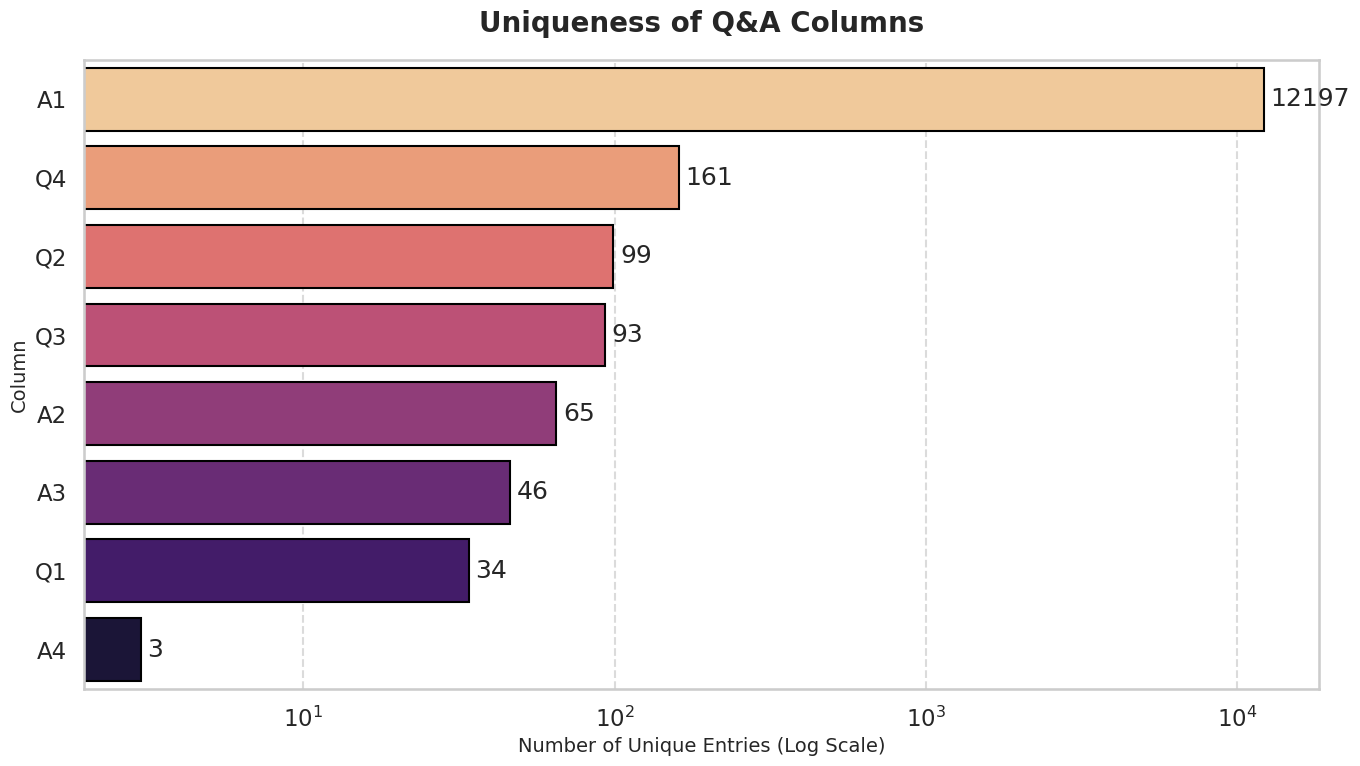

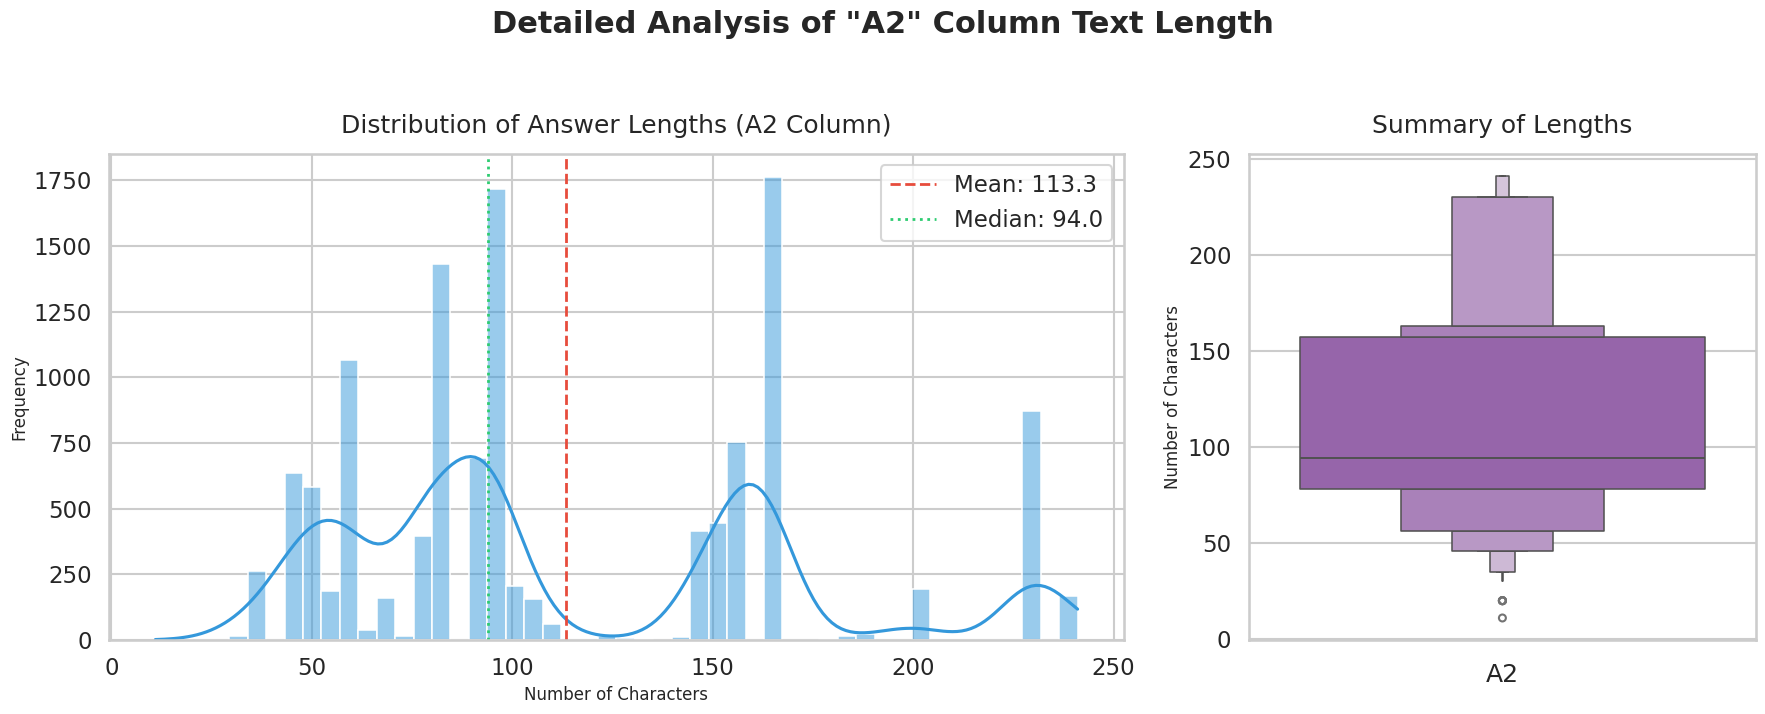

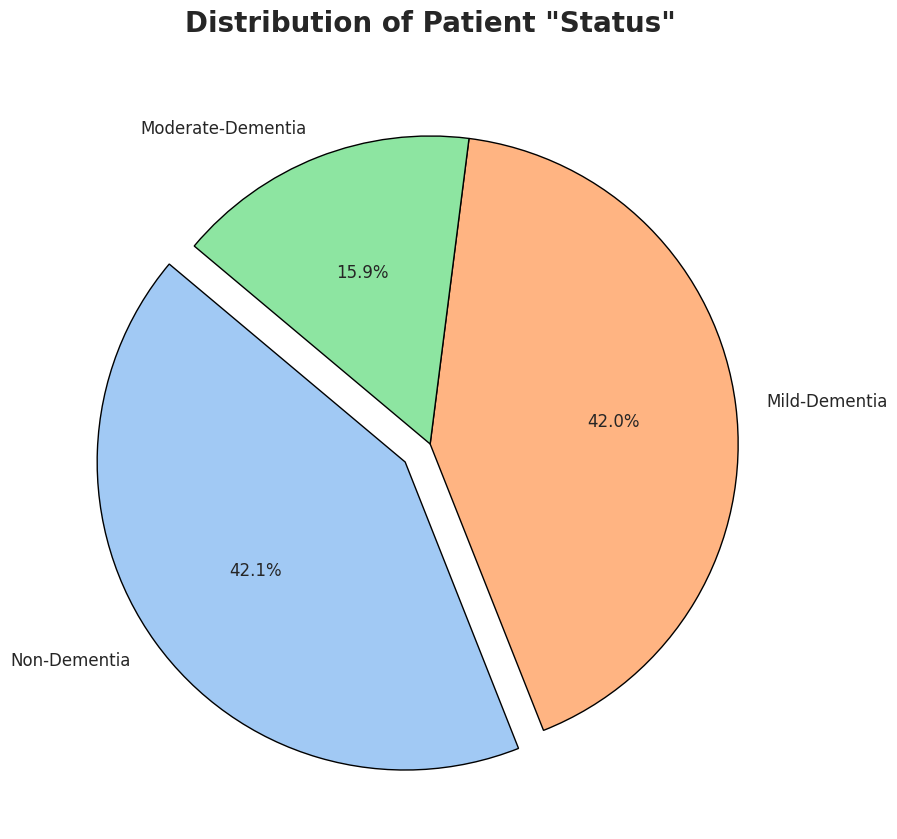

In [12]:
!pip install -q datasets pandas matplotlib seaborn

from datasets import load_dataset, concatenate_datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
from tqdm.auto import tqdm # For progress bars

# --- Configuration ---
HF_DATASET_NAME = "tungvu3196/vlm-projects-multi-lang-final"
subset_name = "Turkish"

# 2. Load the specific 'Vietnamese' subset of the dataset
print(f"Loading the '{subset_name}' subset from the '{HF_DATASET_NAME}' dataset...")
# dataset_subset = load_dataset(HF_DATASET_NAME, name=subset_name)
print("Dataset subset loaded successfully.")
FOCUS_COLUMNS = ['Q1', 'A1', 'Q2', 'A2', 'Q3', 'A3', 'Q4', 'A4']

# --- Step 1: Load and Prepare the Dataset ---
print(f"Loading dataset: {HF_DATASET_NAME}...")
try:
    hf_dataset_dict = load_dataset(HF_DATASET_NAME, name=subset_name)
    print("Dataset loaded successfully.")

    all_splits_list = [split for name, split in hf_dataset_dict.items()]
    if not all_splits_list: raise ValueError("No data splits found.")

    print("\nCombining all splits for a global analysis...")
    combined_dataset = concatenate_datasets(all_splits_list)

    print("\nConverting to pandas DataFrame for analysis (this may take a moment)...")
    df_for_analysis = combined_dataset.to_pandas()
    print(f"Analysis will be performed on {len(df_for_analysis)} total rows.")

except Exception as e:
    print(f"An error occurred: {e}"); exit()


# --- Step 2: Define Analysis Function ---
def analyze_column(df, column_name):
    """Performs a detailed statistical analysis on a specific DataFrame column."""

    # Ensure the column exists
    if column_name not in df.columns:
        print(f"\n--- Analysis for column: '{column_name}' ---")
        print("  Column not found in dataset. Skipping.")
        return None

    print(f"\n--- Analysis for column: '{column_name}' ---")

    stats = {}
    col_series = df[column_name]

    # 1. Completeness
    total_entries = len(col_series)
    # Treat None, NaN, and empty/whitespace-only strings as "missing"
    non_empty_series = col_series.dropna().astype(str).str.strip()
    non_empty_count = non_empty_series[non_empty_series != ''].count()
    missing_count = total_entries - non_empty_count

    stats['Total Rows'] = total_entries
    stats['Non-Empty'] = f"{non_empty_count} ({non_empty_count / total_entries:.1%})"
    stats['Missing/Empty'] = f"{missing_count} ({missing_count / total_entries:.1%})"

    print(f"  Completeness:")
    print(f"    - Total Rows: {stats['Total Rows']}")
    print(f"    - Non-Empty Entries: {stats['Non-Empty']}")
    print(f"    - Missing/Empty Entries: {stats['Missing/Empty']}")

    # 2. Uniqueness
    unique_count = non_empty_series[non_empty_series != ''].nunique()
    stats['Unique Values'] = unique_count
    print(f"  Uniqueness: {unique_count} unique values")

    # 3. Length Analysis (for non-empty strings)
    if non_empty_count > 0:
        char_lengths = non_empty_series[non_empty_series != ''].str.len()
        word_counts = non_empty_series[non_empty_series != ''].str.split().str.len()

        stats['Min Chars'] = int(char_lengths.min())
        stats['Avg Chars'] = f"{char_lengths.mean():.1f}"
        stats['Max Chars'] = int(char_lengths.max())

        stats['Min Words'] = int(word_counts.min())
        stats['Avg Words'] = f"{word_counts.mean():.1f}"
        stats['Max Words'] = int(word_counts.max())

        print("  Text Length (for non-empty values):")
        print(f"    - Characters: Min={stats['Min Chars']}, Avg={stats['Avg Chars']}, Max={stats['Max Chars']}")
        print(f"    - Words: Min={stats['Min Words']}, Avg={stats['Avg Words']}, Max={stats['Max Words']}")

        # 4. Special Analysis for A1 (Bbox count)
        if column_name == 'A1':
            def count_bboxes(bbox_str):
                try:
                    parsed = ast.literal_eval(bbox_str)
                    if isinstance(parsed, list):
                        # Handle nesting like [[...]]
                        if len(parsed) > 0 and isinstance(parsed[0], list):
                            return len(parsed)
                except (ValueError, SyntaxError):
                    return 0 # Not a valid list representation
                return 0

            bbox_counts = non_empty_series[non_empty_series != ''].apply(count_bboxes)
            stats['Avg BBoxes/Entry'] = f"{bbox_counts.mean():.2f}"
            stats['Max BBoxes/Entry'] = int(bbox_counts.max())
            print("  A1 Specific (Bounding Boxes):")
            print(f"    - Avg Boxes per Entry: {stats['Avg BBoxes/Entry']}")
            print(f"    - Max Boxes per Entry: {stats['Max BBoxes/Entry']}")

    # 5. Value Distribution
    print("  Top 5 Most Common Values:")
    if non_empty_count > 0:
        top_5 = non_empty_series[non_empty_series != ''].value_counts().head(5)
        for value, count in top_5.items():
            percentage = count / non_empty_count * 100
            print(f"    - \"{str(value)[:70]}...\" : {count} times ({percentage:.1f}%)")
    else:
        print("    - No values to display.")

    return {column_name: stats}


# --- Step 3: Run Analysis for All Focus Columns ---
all_stats = {}
column_stats_list = []

for column in tqdm(FOCUS_COLUMNS, desc="Analyzing columns"):
    stats_result = analyze_column(df_for_analysis, column)
    if stats_result:
        # For the summary table
        col_stats_for_df = stats_result[column]
        col_stats_for_df['Column'] = column
        column_stats_list.append(col_stats_for_df)
        # For the main dict
        all_stats.update(stats_result)

# --- Step 4: Display Summary Table ---
print("\n" + "="*50)
print(" " * 15 + "DATASET STATISTICS SUMMARY")
print("="*50)

if column_stats_list:
    summary_df = pd.DataFrame(column_stats_list)
    # Reorder columns for clarity
    summary_order = [
        'Column', 'Non-Empty', 'Missing/Empty', 'Unique Values',
        'Avg Chars', 'Min Chars', 'Max Chars', 'Avg Words'
    ]
    # Add A1-specific columns if they exist
    if 'Avg BBoxes/Entry' in summary_df.columns:
        summary_order.extend(['Avg BBoxes/Entry', 'Max BBoxes/Entry'])

    # Filter for columns that actually exist in the summary df
    final_summary_order = [col for col in summary_order if col in summary_df.columns]
    summary_df = summary_df[final_summary_order]

    print(summary_df.to_string(index=False))
else:
    print("No statistics were generated.")
print("="*50)


# --- Step 5: Visualizations ---
# --- Step 5: Visualizations (Enhanced and "Fancier" Version) ---
print("\n" + "="*50)
print(" " * 20 + "VISUALIZATIONS")
print("="*50)

# Set a nice style for all plots
sns.set_theme(style="whitegrid", context="talk")

# 1. Bar chart of unique value counts
if 'summary_df' in locals() and not summary_df.empty:
    unique_counts_df = summary_df[['Column', 'Unique Values']].sort_values('Unique Values', ascending=False)

    plt.figure(figsize=(14, 8))
    # Create the barplot with a nice color palette
    barplot = sns.barplot(
        x='Unique Values',
        y='Column',
        data=unique_counts_df,
        palette='magma_r', # A visually appealing color palette
        edgecolor='black',
        linewidth=1.5
    )

    # --- Add annotations (the actual numbers on the bars) ---
    for p in barplot.patches:
        width = p.get_width()
        plt.text(
            width * 1.05, # Position x: slightly to the right of the bar
            p.get_y() + p.get_height() / 2, # Position y: vertically centered
            f'{int(width)}', # The text to display (count as integer)
            va='center'
        )

    plt.title('Uniqueness of Q&A Columns', fontsize=20, pad=20, weight='bold')
    plt.xlabel('Number of Unique Entries (Log Scale)', fontsize=14)
    plt.ylabel('Column', fontsize=14)
    plt.xscale('log') # Log scale is good for wide-ranging values
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    # Add a bit of margin to the right to fit the annotations
    plt.xlim(right=unique_counts_df['Unique Values'].max() * 1.5)
    plt.tight_layout()
    plt.show()

# 2. Histogram and Boxenplot of text lengths for a key answer column (A2)
if 'A2' in df_for_analysis.columns:
    # Prepare the data
    char_lengths_a2 = df_for_analysis['A2'].dropna().astype(str).str.len()

    # Create a figure with two subplots side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [2, 1]})

    # --- Subplot 1: Histogram (Density Plot) ---
    sns.histplot(
        char_lengths_a2,
        bins=50,
        kde=True,
        ax=axes[0],
        color='#3498db' # A nice blue color
    )
    axes[0].set_title('Distribution of Answer Lengths (A2 Column)', fontsize=18, pad=15)
    axes[0].set_xlabel('Number of Characters', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].axvline(char_lengths_a2.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {char_lengths_a2.mean():.1f}')
    axes[0].axvline(char_lengths_a2.median(), color='#2ecc71', linestyle=':', linewidth=2, label=f'Median: {char_lengths_a2.median():.1f}')
    axes[0].legend()

    # --- Subplot 2: Boxenplot (Enhanced Box Plot) ---
    sns.boxenplot(y=char_lengths_a2, ax=axes[1], color='#9b59b6') # A nice purple color
    axes[1].set_title('Summary of Lengths', fontsize=18, pad=15)
    axes[1].set_ylabel('Number of Characters', fontsize=12)
    axes[1].set_xlabel('A2')

    plt.suptitle('Detailed Analysis of "A2" Column Text Length', fontsize=22, weight='bold', y=1.03)
    plt.tight_layout()
    plt.show()

# 3. Pie chart for 'Status' column distribution
if 'Status' in df_for_analysis.columns:
    status_counts = df_for_analysis['Status'].value_counts()

    # Use a visually distinct color palette
    colors = sns.color_palette('pastel')[0:len(status_counts)]

    plt.figure(figsize=(10, 10))
    # Explode the largest slice slightly for emphasis
    explode = [0.1] + [0] * (len(status_counts) - 1)

    plt.pie(
        status_counts,
        labels=status_counts.index,
        autopct='%1.1f%%', # Format for percentages
        startangle=140,
        colors=colors,
        explode=explode,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1},
        textprops={'fontsize': 12}
    )
    plt.title('Distribution of Patient "Status"', fontsize=20, pad=20, weight='bold')
    plt.ylabel('') # Hide the 'Status' label on the y-axis for a cleaner look
    plt.show()

In [ ]:
!pip install -q datasets pandas matplotlib seaborn

from datasets import load_dataset, concatenate_datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
from tqdm.auto import tqdm

# --- Step 1: Configuration ---
HF_DATASET_NAME = "tungvu3196/vlm-projects-multi-lang-final"
SUBSET_NAME = "Vietnamese" # You can change this to "English", "French", etc.
FOCUS_COLUMNS = ['Q1', 'A1', 'Q2', 'A2', 'Q3', 'A3', 'Q4', 'A4']

# --- Step 2: Load the SPECIFIC SUBSET of the Dataset ---
print(f"Loading the '{SUBSET_NAME}' subset from dataset: {HF_DATASET_NAME}...")
try:
    hf_dataset_dict = load_dataset(HF_DATASET_NAME, name=SUBSET_NAME)
    print(f"Subset '{SUBSET_NAME}' loaded successfully.")
    all_splits_list = [split for name, split in hf_dataset_dict.items()]
    if not all_splits_list: raise ValueError(f"No data splits found in the '{SUBSET_NAME}' subset.")
    combined_dataset_subset = concatenate_datasets(all_splits_list)
    df_for_analysis = combined_dataset_subset.to_pandas()
    print(f"Analysis will be performed on {len(df_for_analysis)} total rows from the '{SUBSET_NAME}' subset.")
except Exception as e:
    print(f"An error occurred: {e}"); exit()


# --- Step 3: Define Analysis Function with Tabular Output ---
def analyze_column(df, column_name):
    """Performs a detailed statistical analysis on a specific DataFrame column."""
    if column_name not in df.columns:
        print(f"\n--- Analysis for column: '{column_name}' ---")
        print("  Column not found in this subset. Skipping.")
        return None
    print(f"\n--- Analysis for column: '{column_name}' ---")
    stats = {}
    col_series = df[column_name]
    total_entries = len(col_series)
    non_empty_series = col_series.dropna().astype(str).str.strip()
    non_empty_count = non_empty_series[non_empty_series != ''].count()
    missing_count = total_entries - non_empty_count
    stats['Total Rows'] = total_entries
    stats['Non-Empty'] = f"{non_empty_count} ({non_empty_count / total_entries:.1%})"
    stats['Missing/Empty'] = f"{missing_count} ({missing_count / total_entries:.1%})"
    print(f"  Completeness: Non-Empty={stats['Non-Empty']}, Missing/Empty={stats['Missing/Empty']}")
    unique_count = non_empty_series[non_empty_series != ''].nunique()
    stats['Unique Values'] = unique_count
    print(f"  Uniqueness: {unique_count} unique values")
    if non_empty_count > 0:
        char_lengths = non_empty_series[non_empty_series != ''].str.len()
        word_counts = non_empty_series[non_empty_series != ''].str.split().str.len()
        stats['Min Chars'] = int(char_lengths.min()); stats['Avg Chars'] = f"{char_lengths.mean():.1f}"; stats['Max Chars'] = int(char_lengths.max())
        stats['Min Words'] = int(word_counts.min()); stats['Avg Words'] = f"{word_counts.mean():.1f}"; stats['Max Words'] = int(word_counts.max())
        print(f"  Text Length: Chars (Min={stats['Min Chars']}, Avg={stats['Avg Chars']}, Max={stats['Max Chars']})")
        if column_name == 'A1':
            def count_bboxes(bbox_str):
                try:
                    parsed = ast.literal_eval(bbox_str)
                    if isinstance(parsed, list) and len(parsed) > 0 and isinstance(parsed[0], list): return len(parsed)
                except: return 0
                return 0
            bbox_counts = non_empty_series[non_empty_series != ''].apply(count_bboxes)
            stats['Avg BBoxes/Entry'] = f"{bbox_counts.mean():.2f}"; stats['Max BBoxes/Entry'] = int(bbox_counts.max())
            print(f"  A1 Specific: Avg Boxes={stats['Avg BBoxes/Entry']}, Max Boxes={stats['Max BBoxes/Entry']}")

    # --- MODIFIED PART ---
    print("  Top 5 Most Common Values:")
    if non_empty_count > 0:
        top_5_series = non_empty_series[non_empty_series != ''].value_counts().head(5)
        top_5_df = pd.DataFrame({'Value': top_5_series.index, 'Count': top_5_series.values})
        top_5_df['Value'] = top_5_df['Value'].str.slice(0, 70).apply(lambda x: x + '...' if len(x) == 70 else x)
        top_5_df['Percentage'] = (top_5_df['Count'] / non_empty_count * 100).map('{:.1f}%'.format)
        print(top_5_df.to_string(index=False))
    else:
        print("    No values to display.")
    # --- END MODIFICATION ---

    return {column_name: stats}


# --- Step 4: Run Analysis and Display Summary Table ---
column_stats_list = []
for column in tqdm(FOCUS_COLUMNS, desc=f"Analyzing columns for {SUBSET_NAME}"):
    stats_result = analyze_column(df_for_analysis, column)
    if stats_result:
        col_stats_for_df = stats_result[column]; col_stats_for_df['Column'] = column
        column_stats_list.append(col_stats_for_df)

print("\n" + "="*60)
print(f"          DATASET STATISTICS SUMMARY FOR '{SUBSET_NAME}' SUBSET")
print("="*60)
if column_stats_list:
    summary_df = pd.DataFrame(column_stats_list)
    summary_order = ['Column', 'Non-Empty', 'Missing/Empty', 'Unique Values', 'Avg Chars', 'Min Chars', 'Max Chars', 'Avg Words']
    if 'Avg BBoxes/Entry' in summary_df.columns: summary_order.extend(['Avg BBoxes/Entry', 'Max BBoxes/Entry'])
    final_summary_order = [col for col in summary_order if col in summary_df.columns]
    summary_df = summary_df[final_summary_order]
    print(summary_df.to_string(index=False))
else:
    print("No statistics were generated.")
print("="*60)


# --- Step 5: Visualizations (Fancier Version) ---
# (The visualization code remains the same and does not need to be changed)
# ... (visualization code block) ...

Loading the 'Vietnamese' subset from dataset: tungvu3196/vlm-projects-multi-lang-final...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/vietnamese/train.parquet:   0%|          | 0.00/1.87G [00:00<?, ?B/s]

data/vietnamese/test.parquet:   0%|          | 0.00/261M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10783 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1542 [00:00<?, ? examples/s]

Subset 'Vietnamese' loaded successfully.
Analysis will be performed on 12325 total rows from the 'Vietnamese' subset.


Analyzing columns for Vietnamese:   0%|          | 0/8 [00:00<?, ?it/s]


--- Analysis for column: 'Q1' ---
  Completeness: Non-Empty=12325 (100.0%), Missing/Empty=0 (0.0%)
  Uniqueness: 33 unique values
  Text Length: Chars (Min=19, Avg=26.8, Max=40)
  Top 5 Most Common Values:
                                   Value  Count Percentage
                  Đánh dấu vùng bị bệnh?    941       7.6%
Xác định/Khoanh vùng khu vực tổn thương?    815       6.6%
          Làm nổi bật vị trí tổn thương?    783       6.4%
                 Nhận dạng vùng bị bệnh?    733       5.9%
                    Nhận dạng vùng bệnh?    699       5.7%

--- Analysis for column: 'A1' ---
  Completeness: Non-Empty=12325 (100.0%), Missing/Empty=0 (0.0%)
  Uniqueness: 12197 unique values
  Text Length: Chars (Min=24, Avg=266.6, Max=661)
  A1 Specific: Avg Boxes=3.23, Max Boxes=8
  Top 5 Most Common Values:
                                             Value  Count Percentage
                         [[0.5, 0.65, 0.43, 0.15]]    111       0.9%
                         [[0.5, 0.63, 0.43, 0.